# Construction d'un GVAR global avec trois zones : USA, Europe et Japon

In [1]:
import pandas as pd
import numpy as np

## Analyse et Compréhension des bases de données TES

In [2]:
data_tes = pd.read_csv(
    "data/international_TES/2013_SML.csv",
    index_col=0,
    low_memory=False
)

data_tes.head()
print(data_tes.shape)

(3468, 3928)


In [3]:
print(data_tes.index[-10:])

Index(['ROW_N', 'ROW_O', 'ROW_P', 'ROW_Q', 'ROW_R', 'ROW_S', 'ROW_T', 'TLS',
       'VA', 'OUT'],
      dtype='str', name='V1')


In [4]:
print(data_tes.columns[-20:])

Index(['USA_DPABR', 'VNM_HFCE', 'VNM_NPISH', 'VNM_GGFC', 'VNM_GFCF',
       'VNM_INVNT', 'VNM_DPABR', 'ZAF_HFCE', 'ZAF_NPISH', 'ZAF_GGFC',
       'ZAF_GFCF', 'ZAF_INVNT', 'ZAF_DPABR', 'ROW_HFCE', 'ROW_NPISH',
       'ROW_GGFC', 'ROW_GFCF', 'ROW_INVNT', 'ROW_DPABR', 'OUT'],
      dtype='str')


In [5]:
cols = data_tes.columns

fd_start = [i for i, col in enumerate(cols) if "HFCE" in col][0]

print("FD commence à la colonne :", fd_start)
print("Nom de la colonne :", cols[fd_start])

FD commence à la colonne : 3465
Nom de la colonne : ARG_HFCE


In [6]:
FD_cols = data_tes.columns[fd_start:-1]  # -1 pour exclure OUT

print("Nombre colonnes FD :", len(FD_cols))
print(FD_cols[:10])
print(FD_cols[-10:])

Nombre colonnes FD : 462
Index(['ARG_HFCE', 'ARG_NPISH', 'ARG_GGFC', 'ARG_GFCF', 'ARG_INVNT',
       'ARG_DPABR', 'AUS_HFCE', 'AUS_NPISH', 'AUS_GGFC', 'AUS_GFCF'],
      dtype='str')
Index(['ZAF_GGFC', 'ZAF_GFCF', 'ZAF_INVNT', 'ZAF_DPABR', 'ROW_HFCE',
       'ROW_NPISH', 'ROW_GGFC', 'ROW_GFCF', 'ROW_INVNT', 'ROW_DPABR'],
      dtype='str')


In [7]:
df_nace = pd.read_excel("data/international_TES/NACE 38 - 88 detaille vf.xlsx")

df_nace["NACE 17"] = df_nace["NACE 17"].ffill()
secteurs_uniques = df_nace["NACE 17"].unique()

print("Nombre de secteurs uniques :", len(secteurs_uniques))
print(sorted(secteurs_uniques))

Nombre de secteurs uniques : 18
['AZ', 'BZ', 'C1', 'C2', 'C3', 'C4', 'C5', 'CH', 'FZ', 'GZ', 'HZ', 'IZ', 'JZ', 'KZ', 'LZ', 'MN', 'OQ', 'RU']


In [8]:
# Charger le fichier Excel
df_read = pd.read_excel("data/international_TES/ReadME_ICIO_small.xlsx")

# Afficher les premières lignes
df_read.head(100)

c:\Users\HP\PFE\.venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: ColItems!$A:$A.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\HP\PFE\.venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: RowItems!$A:$A.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,NaN,"OECD, Inter-Country Input-Output (ICIO) Tables",NaN
1,NaN,NaN,NaN
2,NaN,NaN,http://oe.cd/icio
3,NaN,NaN,NaN
4,NaN,Suggestions or queries can be sent to icio-tiv...,NaN
5,NaN,"When using this database, please cite as ""OECD...",NaN
6,NaN,NaN,NaN
7,NaN,NaN,"Data are expressed in current USD, million"
8,NaN,NaN,Structure
9,NaN,NaN,Reference area & economic activities


In [9]:
xls = pd.ExcelFile("data/international_TES/ReadME_ICIO_small.xlsx")
print(xls.sheet_names)

c:\Users\HP\PFE\.venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: ColItems!$A:$A.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


['ReadMe', 'Structure', 'Area_Activities', 'RowItems', 'ColItems']


c:\Users\HP\PFE\.venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: RowItems!$A:$A.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


In [10]:
df_area = pd.read_excel(
    "data/international_TES/ReadME_ICIO_small.xlsx",
    sheet_name="Area_Activities",
    skiprows=2)

# enlever colonnes vides éventuelles
df_area = df_area.dropna(axis=1, how="all")

df_area.head()

,V1,Code,Column1,countries,V1.1,Old code,Code.1,Industry,ISIC Rev.4
0,1,ARG,NaN,Argentina,1.0,D01T02,A01_02,"Agriculture, hunting, forestry","01, 02"
1,2,AUS,NaN,Australia,2.0,D03,A03,Fishing and aquaculture,03
2,3,AUT,NaN,Austria,3.0,D05T06,B05_06,"Mining and quarrying, energy producing products","05, 06"
3,4,BEL,NaN,Belgium,4.0,D07T08,B07_08,"Mining and quarrying, non-energy producing pro...","07, 08"
4,5,BGD,NaN,Bangladesh,5.0,D09,B09,Mining support service activities,09


In [11]:
df_area.columns

Index(['V1', 'Code', 'Column1', 'countries', 'V1.1', 'Old code', 'Code.1',
       'Industry', 'ISIC Rev.4'],
      dtype='str')

In [12]:
df_area.columns = [
    "col0",          # colonne vide
    "country_code",  # ARG, AUS, FRA...
    "col2",
    "country_name",  # Argentina, Australia...
    "col4",
    "old_code",
    "sector_code",   # A01_02, C10T12...
    "sector_name",
    "isic"
]

Extraction de la liste des pays 

In [13]:
liste_pays_code = df_area["country_code"].unique()
liste_pays = df_area["country_name"].unique()

print("Nombre de pays :", len(liste_pays_code))
print(liste_pays_code[:77])

print("Noms de pays :", len(liste_pays))
print(liste_pays[:77])

Nombre de pays : 78
<StringArray>
['ARG', 'AUS', 'AUT', 'BEL', 'BGD', 'BGR', 'BLR', 'BRA', 'BRN', 'CAN', 'CHE',
 'CHL', 'CHN', 'CIV', 'CMR', 'COL', 'CRI', 'CYP', 'CZE', 'DEU', 'DNK', 'EGY',
 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HKG', 'HRV', 'HUN', 'IDN', 'IND',
 'IRL', 'ISL', 'ISR', 'ITA', 'JOR', 'JPN', 'KAZ', 'KHM', 'KOR', 'LAO', 'LTU',
 'LUX', 'LVA', 'MAR', 'MEX', 'MLT', 'MMR', 'MYS', 'NGA', 'NLD', 'NOR', 'NZL',
 'PAK', 'PER', 'PHL', 'POL', 'PRT', 'ROU', 'RUS', 'SAU', 'SEN', 'SGP', 'SVK',
 'SVN', 'SWE', 'THA', 'TUN', 'TUR', 'TWN', 'UKR', 'USA', 'VNM', 'ZAF', 'ROW']
Length: 77, dtype: str
Noms de pays : 78
<StringArray>
[                         'Argentina',                          'Australia',
                            'Austria',                            'Belgium',
                         'Bangladesh',                           'Bulgaria',
                            'Belarus',                             'Brazil',
                  'Brunei Darussalam',                   

In [14]:
liste_secteurs = df_area["sector_code"].unique()
liste_secteurs_name = df_area["sector_name"].unique()

print("Nombre de secteurs :", len(liste_secteurs))
print(liste_secteurs[:45])
liste_secteurs = df_area["sector_code"].unique()

print("Nombre de secteurs :", len(liste_secteurs_name))
print(liste_secteurs_name[:45])

Nombre de secteurs : 46
<StringArray>
['A01_02',    'A03', 'B05_06', 'B07_08',    'B09', 'C10T12', 'C13T15',
    'C16', 'C17_18',    'C19',    'C20',    'C21',    'C22',    'C23',
    'C24',    'C25',    'C26',    'C27',    'C28',    'C29',    'C30',
 'C31T33',      'D',      'E',      'F',      'G',    'H49',    'H50',
    'H51',    'H52',    'H53',      'I', 'J58T60',    'J61', 'J62_63',
      'K',      'L',      'M',      'N',      'O',      'P',      'Q',
      'R',      'S',      'T']
Length: 45, dtype: str
Nombre de secteurs : 46
<StringArray>
[                                                                                            'Agriculture, hunting, forestry',
                                                                                                    'Fishing and aquaculture',
                                                                            'Mining and quarrying, energy producing products',
                                                               

In [15]:
years = range(2011, 2021)

data = {}

for year in years:
    df = pd.read_csv(
        f"data/international_TES/{year}_SML.csv",
        index_col=0,
        low_memory=False
    )
    data[year] = df

In [16]:
data[2015].head()

,ARG_A01_02,ARG_A03,ARG_B05_06,ARG_B07_08,ARG_B09,ARG_C10T12,ARG_C13T15,ARG_C16,ARG_C17_18,ARG_C19,...,ZAF_GFCF,ZAF_INVNT,ZAF_DPABR,ROW_HFCE,ROW_NPISH,ROW_GGFC,ROW_GFCF,ROW_INVNT,ROW_DPABR,OUT
V1,,,,,,,,,,,,,,,,,,,,,
ARG_A01_02,7021.3450,22.3506,3.6788,3.1605,0.0000,29534.1193,1544.6489,113.8678,98.7946,6.3076,...,1.3954,0.8413,0.0498,746.6062,0.0972,9.3747,30.6841,28.1839,4.9681,59311.9484
ARG_A03,7.9760,72.6433,0.0408,0.0007,0.0064,612.4146,0.0450,0.0020,0.1803,0.2672,...,0.0000,0.0066,0.0054,19.6399,0.0075,0.0364,0.0070,0.3486,0.5387,2235.9896
ARG_B05_06,5.3907,0.1209,360.9753,10.0700,42.5685,15.8616,2.5260,0.7495,1.7184,10825.5522,...,0.0033,0.0005,0.0003,0.4741,0.0002,0.0065,1.0814,0.8194,0.0257,21997.2584
ARG_B07_08,0.9832,0.2743,76.6361,511.8613,0.0224,111.9267,10.5371,0.0520,8.3223,139.5662,...,0.0004,0.0000,0.0000,7.7400,0.0000,0.0000,0.0924,0.2624,0.0000,6206.7158
ARG_B09,0.0000,0.0000,4252.0885,86.9235,156.7731,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1675,0.0000,0.0000,4996.7422


## Construction de la matrice de poids W

### Chargement des données, filtrage pour les bases des données et extraction Z domestique (pays/zone)

In [17]:
import os
import numpy as np
import pandas as pd

FD_SUFFIXES = ["HFCE", "NPISH", "GGFC", "GFCF", "INVNT", "DPABR"]

def load_icio_year(path_csv: str) -> pd.DataFrame:
    """Charge un ICIO annuel (CSV) avec la 1ère colonne en index."""
    df = pd.read_csv(path_csv, index_col=0, low_memory=False)
    return df

def find_fd_start(columns: pd.Index) -> int:
    """Retourne l'index de la 1ère colonne de demande finale (HFCE)."""
    for i, c in enumerate(columns):
        if any(c.endswith("_" + sfx) for sfx in FD_SUFFIXES):
            return i
    raise ValueError("Impossible de trouver le début de la demande finale (HFCE...).")

def get_sector_rows(df: pd.DataFrame) -> pd.Index:
    """Garde uniquement les lignes secteurs pays (exclut TLS/VA/OUT)."""
    # Dans tes fichiers : les 3 dernières lignes sont TLS, VA, OUT
    # On les enlève si elles existent.
    drop_last = [x for x in ["TLS", "VA", "OUT"] if x in df.index]
    if drop_last:
        df_sect = df.drop(index=drop_last)
        return df_sect.index
    return df.index

def get_sector_cols(df: pd.DataFrame) -> pd.Index:
    """Retourne uniquement les colonnes secteurs (exclut FD et OUT)."""
    fd_start = find_fd_start(df.columns)
    # -1 pour exclure la colonne OUT (dernière colonne)
    return df.columns[:fd_start]

def extract_country_intermediate_matrix(df: pd.DataFrame, area_code: str) -> pd.DataFrame:
    """
    Extrait la sous-matrice Z domestique (industries x industries) pour un pays/zone.
    area_code: 'USA', 'FRA', 'DEU', 'ROW', etc.
    """
    # lignes secteurs seulement
    df_sect = df.loc[get_sector_rows(df), :]

    # colonnes secteurs seulement
    sector_cols = get_sector_cols(df)

    # sous-matrice complète Z (tous pays/secteurs)
    Z_full = df_sect[sector_cols]

    # filtre domestique: lignes et colonnes qui commencent par "USA_"
    prefix = area_code + "_"
    rows_dom = [idx for idx in Z_full.index if idx.startswith(prefix)]
    cols_dom = [col for col in Z_full.columns if col.startswith(prefix)]

    Z_dom = Z_full.loc[rows_dom, cols_dom].copy()
    return Z_dom


### Mapping 45 secteurs ICIO → 17 NACE (matrice de passage)

In [18]:
macro_map = {
    "AZ": "Primaires & énergie",
    "BZ": "Primaires & énergie",

    "FZ": "Construction & immobilier",
    "LZ": "Construction & immobilier",

    "JZ": "Info-com",

    "GZ": "Services",
    "IZ": "Services",
    "HZ": "Services",

    "KZ": "Finance",

    "OQ": "Public & services non-marchands",
    "RU": "Public & services non-marchands",

    "MN": "Services pro",

    "C1": "Industrie",
    "C2": "Industrie",
    "C3": "Industrie",
    "C4": "Industrie",
    "C5": "Industrie",
    "CH": "Industrie",
}

In [19]:
def load_nace_mapping(path_xlsx: str) -> dict:
    m = pd.read_excel(path_xlsx)

    # Forward fill du NACE 17
    m["NACE 17"] = m["NACE 17"].ffill()

    # Nettoyage
    m["Nace 88"] = m["Nace 88"].astype(str).str.strip()
    m["NACE 17"] = m["NACE 17"].astype(str).str.strip()

    # Supprimer lignes vides
    m = m.dropna(subset=["Nace 88"])

    return dict(zip(m["Nace 88"], m["NACE 17"]))


def split_area_sector(code: str) -> tuple[str, str]:
    """
    'USA_A01_02' -> ('USA', 'A01_02')
    Attention: certains secteurs contiennent des underscores (C17_18, J62_63 etc.)
    On retire juste le préfixe pays + '_' et on garde le reste.
    """
    area, rest = code.split("_", 1)
    return area, rest

def aggregate_45_to_17(Z_dom_45: pd.DataFrame, map_45_to_17: dict) -> pd.DataFrame:
    """
    Agrège une matrice domestique (45x45, index/cols 'USA_<sec45>')
    en (17x17) selon la table de passage.
    """
    # extraire codes secteur 45
    row_sectors_45 = [split_area_sector(x)[1] for x in Z_dom_45.index]
    col_sectors_45 = [split_area_sector(x)[1] for x in Z_dom_45.columns]

    # mapper vers NACE17
    row_sec17 = [map_45_to_17.get(s, None) for s in row_sectors_45]
    col_sec17 = [map_45_to_17.get(s, None) for s in col_sectors_45]

    if any(v is None for v in row_sec17):
        missing = sorted({s for s, v in zip(row_sectors_45, row_sec17) if v is None})
        raise ValueError(f"Secteurs 45 manquants dans mapping (lignes): {missing[:15]} ...")

    if any(v is None for v in col_sec17):
        missing = sorted({s for s, v in zip(col_sectors_45, col_sec17) if v is None})
        raise ValueError(f"Secteurs 45 manquants dans mapping (colonnes): {missing[:15]} ...")

    # construire DF avec index/cols NACE17 (en gardant valeurs)
    Z_tmp = Z_dom_45.copy()
    Z_tmp.index = row_sec17
    Z_tmp.columns = col_sec17

    # agréger par somme (groupby sur index puis sur colonnes)
    Z_17 = Z_tmp.groupby(level=0).sum()
    Z_17 = Z_17.T.groupby(level=0).sum().T

    # ordonner les secteurs pour stabilité (optionnel)
    Z_17 = Z_17.sort_index().sort_index(axis=1)
    return Z_17

In [20]:
def aggregate_matrix_by_mapping(
    Z_matrix: pd.DataFrame,
    mapping_dict: dict
) -> pd.DataFrame:
    """
    Agrège une matrice carrée selon un mapping secteur -> groupe.
    Compatible avec :
      - NACE17
      - Macro-groupes personnalisés
    """

    # Vérification
    missing = sorted(set(Z_matrix.index) - set(mapping_dict.keys()))
    if missing:
        raise ValueError(f"Secteurs non mappés: {missing}")

    Z_tmp = Z_matrix.copy()

    # Remplacement index / colonnes
    Z_tmp.index = Z_tmp.index.map(mapping_dict)
    Z_tmp.columns = Z_tmp.columns.map(mapping_dict)

    # Agrégation par somme
    Z_agg = Z_tmp.groupby(level=0).sum()
    Z_agg = Z_agg.T.groupby(level=0).sum().T

    return Z_agg.sort_index().sort_index(axis=1)

### Moyenne 2011–2020 + construction de W

In [21]:
def extract_zone_to_zone_intermediate_matrix(
    df: pd.DataFrame,
    row_area_codes: list[str],
    col_area_codes: list[str]
):
    df_sect = df.loc[get_sector_rows(df), :]
    sector_cols = get_sector_cols(df)

    Z_full = df_sect[sector_cols]

    row_prefixes = tuple(code + "_" for code in row_area_codes)
    col_prefixes = tuple(code + "_" for code in col_area_codes)

    rows_sel = [idx for idx in Z_full.index if idx.startswith(row_prefixes)]
    cols_sel = [col for col in Z_full.columns if col.startswith(col_prefixes)]

    return Z_full.loc[rows_sel, cols_sel].copy()

In [22]:
def average_zone_to_zone_block(
    data_dir,
    years,
    row_area_codes,
    col_area_codes,
    mapping_xlsx
):

    map_45_to_17 = load_nace_mapping(mapping_xlsx)
    mats = []

    for y in years:

        path = os.path.join(data_dir, f"{y}_SML.csv")
        df_y = load_icio_year(path)

        Z_block_45 = extract_zone_to_zone_intermediate_matrix(
            df_y,
            row_area_codes,
            col_area_codes
        )

        Z_block_17 = aggregate_45_to_17(Z_block_45, map_45_to_17)

        Z_block_8 = aggregate_matrix_by_mapping(Z_block_17, macro_map)

        mats.append(Z_block_8)

    return sum(mats) / len(mats)

In [23]:
def build_Xbar_three_zones(
    data_dir,
    years,
    zones,
    mapping_xlsx
):

    zone_names = list(zones.keys())
    block_rows = []

    for row_zone in zone_names:

        row_blocks = []

        for col_zone in zone_names:

            X_block = average_zone_to_zone_block(
                data_dir,
                years,
                zones[row_zone],
                zones[col_zone],
                mapping_xlsx
            )

            row_blocks.append(X_block)

        big_row = pd.concat(row_blocks, axis=1)
        block_rows.append(big_row)

    X_big = pd.concat(block_rows, axis=0)

    sector_order = row_blocks[0].index

    full_index = []
    for z in zone_names:
        full_index += [f"{z}_{s}" for s in sector_order]

    full_columns = []
    for z in zone_names:
        full_columns += [f"{z}_{s}" for s in sector_order]

    X_big.index = full_index
    X_big.columns = full_columns

    return X_big

In [24]:
def build_W_gvar(X_bar: pd.DataFrame) -> pd.DataFrame:
    """
    Construit la matrice de poids W à partir de X_bar (17x17)
    selon :
      1. Neutralisation de la diagonale
      2. Normalisation ligne par ligne
    """

    # Copie pour éviter modification in-place
    X_star = X_bar.copy()

    # 1️⃣ Neutralisation auto-dépendance
    X_star_values = X_star.to_numpy().copy()
    np.fill_diagonal(X_star_values, 0.0)
    X_star.iloc[:, :] = X_star_values

    # 2️⃣ Somme des flux sortants (hors diagonale)
    row_sums = X_star.sum(axis=1)

    # Eviter division par zéro
    row_sums = row_sums.replace(0, np.nan)

    # 3️⃣ Normalisation ligne par ligne
    W = X_star.div(row_sums, axis=0)

    # Remettre les éventuels NaN à 0
    W = W.fillna(0.0)

    return W


In [25]:
DATA_DIR = "data/international_TES"
MAPPING_XLSX = "data/international_TES/NACE 38 - 88 detaille vf.xlsx"
YEARS = list(range(2011, 2021))

In [26]:
EU_CODES = [
    "AUT","BEL","BGR","CYP","CZE","DEU","DNK","ESP","EST","FIN","FRA","GRC",
    "HRV","HUN","IRL","ITA","LTU","LUX","LVA","MLT","NLD","POL","PRT","ROU",
    "SVK","SVN","SWE"
]

ZONES = {
    "USA": ["USA"],
    "EU": EU_CODES,
    "JP": ["JPN"]
}

Xbar_global = build_Xbar_three_zones(
    DATA_DIR,
    YEARS,
    ZONES,
    MAPPING_XLSX
)

W_global = build_W_gvar(Xbar_global)

print(Xbar_global.shape)
print(W_global.shape)
print(W_global.sum(axis=1))

(24, 24)
(24, 24)
USA_Construction & immobilier          1.0
USA_Finance                            1.0
USA_Industrie                          1.0
USA_Info-com                           1.0
USA_Primaires & énergie                1.0
USA_Public & services non-marchands    1.0
USA_Services                           1.0
USA_Services pro                       1.0
EU_Construction & immobilier           1.0
EU_Finance                             1.0
EU_Industrie                           1.0
EU_Info-com                            1.0
EU_Primaires & énergie                 1.0
EU_Public & services non-marchands     1.0
EU_Services                            1.0
EU_Services pro                        1.0
JP_Construction & immobilier           1.0
JP_Finance                             1.0
JP_Industrie                           1.0
JP_Info-com                            1.0
JP_Primaires & énergie                 1.0
JP_Public & services non-marchands     1.0
JP_Services                         

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
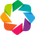

In [27]:
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

def plot_chord(matrix, threshold=0.05, title="Liens sectoriels"):

    # format long
    df_long = (
        matrix
        .reset_index()
        .melt(id_vars=matrix.index.name if matrix.index.name else "index")
    )

    df_long.columns = ["source", "target", "value"]

    # retirer diagonale
    df_long = df_long[df_long["source"] != df_long["target"]]

    # filtrer petits poids
    df_long = df_long[df_long["value"] > threshold]

    # créer liste des secteurs
    secteurs = list(matrix.index)

    nodes = pd.DataFrame({
        "index": secteurs,
        "name": secteurs
    })

    # créer chord
    chord = hv.Chord((df_long, hv.Dataset(nodes, 'index')))

    chord = chord.opts(
        opts.Chord(
            cmap='Category20',
            edge_cmap='Category20',
            labels='name',
            node_color='index',
            edge_color='source',
            edge_alpha=0.7,
            width=700,
            height=700,
            title=title
        )
    )

    return chord

In [28]:
plot_chord(W_global, threshold=0.005, title="Weights matrix, threshold 0.005")

:Chord   [source,target]   (value)

In [29]:
plot_chord(W_global, threshold=0.01, title="Weights matrix, threshold 0.01")

:Chord   [source,target]   (value)

In [30]:
plot_chord(W_global, threshold=0.05, title="Weights matrix, threshold 0.05")

:Chord   [source,target]   (value)

## Implémentation du GVAR global avec les trois zones

### Gestion des Z

In [49]:
# ====== PARAMETRES DU MODELE ======
P = 0       # lags sur Z_i (domestique) : 1..P
P_star = 1  # lags sur Z_i* (étranger) : 0..P_star
L = 1       # lags sur X (macro) : 0..L

In [50]:
Z_FOLDER_US = "data/facteurs_systemiq/zt_am/zt_by_sector.csv"
Z_FOLDER_EU = "data/facteurs_systemiq/zt_eu/zt_by_sector.csv"
Z_FOLDER_JP = "data/facteurs_systemiq/zt_jp/zt_by_sector.csv"

MACRO_PATH = "data/macro_data/df_macro_stationary.csv"

OUTPUT_DIR = "data/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [42]:
def load_Z_single_csv(path_csv: str) -> pd.DataFrame:
    """
    Charge un seul CSV contenant :
    sector, year_quarter, z_t
    et le transforme en matrice (date × secteur)
    """
    df = pd.read_csv(path_csv)

    df["year_quarter"] = pd.to_datetime(df["year_quarter"])

    # Pivot : lignes = date, colonnes = secteur
    Z = df.pivot(
        index="year_quarter",
        columns="sector",
        values="z_t"
    )

    Z = Z.sort_index()

    return Z

In [43]:
Z_us = load_Z_single_csv(Z_FOLDER_US)
Z_eu = load_Z_single_csv(Z_FOLDER_EU)
Z_jp = load_Z_single_csv(Z_FOLDER_JP)

In [44]:
Z_us.head()

sector,construction_immo,extraction_primaire,finance,industrie,info-com,public,services,services_pro
year_quarter,,,,,,,,
2010-07-01,-3.119644,2.534563,-0.787857,-0.014226,-3.292670,-1.474542,-2.020280,-2.270018
2010-10-01,-1.660812,0.635930,-1.219453,0.355094,-0.684983,-0.687493,-1.182131,-1.597358
2011-01-01,1.428445,0.751486,-2.079168,0.798452,-0.435846,-0.815319,-1.175695,-2.016439
2011-04-01,1.800480,1.284856,-1.264702,0.586932,-0.255213,0.220045,-1.503071,-2.016439
2011-07-01,1.929722,1.030703,-1.649227,-0.020633,-0.246125,0.218599,-0.750586,-2.016439


In [45]:
def add_zone_prefix(Z: pd.DataFrame, zone_name: str) -> pd.DataFrame:
    Z_out = Z.copy()
    if "sector" in Z_out.columns:
        Z_out = Z_out.drop(columns="sector")
    Z_out.columns = [f"{zone_name}_{col}" for col in Z_out.columns]
    return Z_out

Z_global = pd.concat(
    [
        add_zone_prefix(Z_us, "USA"),
        add_zone_prefix(Z_eu, "EU"),
        add_zone_prefix(Z_jp, "JP"),
    ],
    axis=1
)

In [46]:
Z_global.head()

,USA_construction_immo,USA_extraction_primaire,USA_finance,USA_industrie,USA_info-com,USA_public,USA_services,USA_services_pro,EU_construction_immo,EU_extraction_primaire,...,EU_services,EU_services_pro,JP_construction_immo,JP_extraction_primaire,JP_finance,JP_industrie,JP_info-com,JP_public,JP_services,JP_services_pro
year_quarter,,,,,,,,,,,,,,,,,,,,,
2010-07-01,-3.119644,2.534563,-0.787857,-0.014226,-3.292670,-1.474542,-2.020280,-2.270018,3.301088,-2.422665,...,-2.414472,-2.815960,2.965820,0.601476,0.741085,1.806367,2.744755,-3.846173,2.908471,0.879218
2010-10-01,-1.660812,0.635930,-1.219453,0.355094,-0.684983,-0.687493,-1.182131,-1.597358,3.303540,0.100671,...,-1.901096,2.807257,1.868407,0.601476,0.741085,1.806367,2.744755,-3.846173,2.908471,0.879218
2011-01-01,1.428445,0.751486,-2.079168,0.798452,-0.435846,-0.815319,-1.175695,-2.016439,3.303540,0.100671,...,-0.726112,2.807257,1.868407,0.601476,0.741085,1.806367,2.744755,-3.846173,2.908471,0.879218
2011-04-01,1.800480,1.284856,-1.264702,0.586932,-0.255213,0.220045,-1.503071,-2.016439,3.303590,-0.877461,...,-1.571767,1.432997,1.868407,0.601476,0.741085,1.125655,2.744755,-3.846173,2.910262,0.879218
2011-07-01,1.929722,1.030703,-1.649227,-0.020633,-0.246125,0.218599,-0.750586,-2.016439,3.303590,-0.877461,...,-1.665124,1.432997,1.868407,0.601476,0.741085,1.125655,2.744755,-3.846173,2.910262,0.879218


In [47]:
W_global.head()

,USA_Construction & immobilier,USA_Finance,USA_Industrie,USA_Info-com,USA_Primaires & énergie,USA_Public & services non-marchands,USA_Services,USA_Services pro,EU_Construction & immobilier,EU_Finance,...,EU_Services,EU_Services pro,JP_Construction & immobilier,JP_Finance,JP_Industrie,JP_Info-com,JP_Primaires & énergie,JP_Public & services non-marchands,JP_Services,JP_Services pro
USA_Construction & immobilier,0.000000,0.091757,0.044284,0.042300,0.031815,0.351467,0.319762,0.118087,0.000032,0.000022,...,0.000077,0.000034,0.000062,0.000015,0.000021,0.000033,0.000004,0.000042,0.000099,0.000014
USA_Finance,0.242649,0.000000,0.060554,0.028523,0.049171,0.256344,0.177896,0.138022,0.006093,0.014663,...,0.004802,0.002893,0.001951,0.000462,0.000699,0.000166,0.000190,0.000872,0.001039,0.000319
USA_Industrie,0.215195,0.015679,0.000000,0.044214,0.104648,0.278254,0.212215,0.070782,0.002494,0.000147,...,0.003920,0.001561,0.000827,0.000067,0.009033,0.000190,0.000421,0.001632,0.002861,0.000273
USA_Info-com,0.055863,0.095590,0.060843,0.000000,0.023014,0.285491,0.222604,0.216516,0.000715,0.001780,...,0.004856,0.006099,0.000221,0.000589,0.001010,0.001222,0.000162,0.000740,0.001217,0.001057
USA_Primaires & énergie,0.121913,0.008160,0.592510,0.008091,0.000000,0.109014,0.111868,0.026744,0.000449,0.000013,...,0.000571,0.000128,0.000289,0.000007,0.006073,0.000006,0.001620,0.000151,0.000707,0.000043


In [48]:
# alignement sur W

rename_dict = {
    "USA_construction_immo": "USA_Construction & immobilier",
    "USA_extraction_primaire": "USA_Primaires & énergie",
    "USA_finance": "USA_Finance",
    "USA_industrie": "USA_Industrie",
    "USA_info-com": "USA_Info-com",
    "USA_public": "USA_Public & services non-marchands",
    "USA_services": "USA_Services",
    "USA_services_pro": "USA_Services pro",
    "EU_construction_immo": "EU_Construction & immobilier",
    "EU_extraction_primaire": "EU_Primaires & énergie",
    "EU_finance": "EU_Finance",
    "EU_industrie": "EU_Industrie",
    "EU_info-com": "EU_Info-com",
    "EU_public": "EU_Public & services non-marchands",
    "EU_services": "EU_Services",
    "EU_services_pro": "EU_Services pro",
    "JP_construction_immo": "JP_Construction & immobilier",
    "JP_extraction_primaire": "JP_Primaires & énergie",
    "JP_finance": "JP_Finance",
    "JP_industrie": "JP_Industrie",
    "JP_info-com": "JP_Info-com",
    "JP_public": "JP_Public & services non-marchands",
    "JP_services": "JP_Services",
    "JP_services_pro": "JP_Services pro"
}

Z_global = Z_global.rename(columns=rename_dict)

Z_global = Z_global[W_global.columns]

print(Z_global.shape)
Z_global.head()

(52, 24)


,USA_Construction & immobilier,USA_Finance,USA_Industrie,USA_Info-com,USA_Primaires & énergie,USA_Public & services non-marchands,USA_Services,USA_Services pro,EU_Construction & immobilier,EU_Finance,...,EU_Services,EU_Services pro,JP_Construction & immobilier,JP_Finance,JP_Industrie,JP_Info-com,JP_Primaires & énergie,JP_Public & services non-marchands,JP_Services,JP_Services pro
year_quarter,,,,,,,,,,,,,,,,,,,,,
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,3.301088,-3.013215,...,-2.414472,-2.815960,2.965820,0.741085,1.806367,2.744755,0.601476,-3.846173,2.908471,0.879218
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,3.303540,2.312740,...,-1.901096,2.807257,1.868407,0.741085,1.806367,2.744755,0.601476,-3.846173,2.908471,0.879218
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439,3.303540,2.312740,...,-0.726112,2.807257,1.868407,0.741085,1.806367,2.744755,0.601476,-3.846173,2.908471,0.879218
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,3.303590,1.862764,...,-1.571767,1.432997,1.868407,0.741085,1.125655,2.744755,0.601476,-3.846173,2.910262,0.879218
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439,3.303590,1.834131,...,-1.665124,1.432997,1.868407,0.741085,1.125655,2.744755,0.601476,-3.846173,2.910262,0.879218


In [124]:
Z_global.columns

Index(['USA_Construction & immobilier', 'USA_Finance', 'USA_Industrie',
       'USA_Info-com', 'USA_Primaires & énergie',
       'USA_Public & services non-marchands', 'USA_Services',
       'USA_Services pro', 'EU_Construction & immobilier', 'EU_Finance',
       'EU_Industrie', 'EU_Info-com', 'EU_Primaires & énergie',
       'EU_Public & services non-marchands', 'EU_Services', 'EU_Services pro',
       'JP_Construction & immobilier', 'JP_Finance', 'JP_Industrie',
       'JP_Info-com', 'JP_Primaires & énergie',
       'JP_Public & services non-marchands', 'JP_Services', 'JP_Services pro'],
      dtype='str')

### Gestion des variables macroéconomiques

In [51]:
df_macro_stas = pd.read_csv("data\macro_data\df_macro_stationary.csv")

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_1440\1462194482.py:1: SyntaxWarning: invalid escape sequence '\m'
  df_macro_stas = pd.read_csv("data\macro_data\df_macro_stationary.csv")


In [52]:
# Convertir la date en datetime
df_macro_stas["date"] = pd.to_datetime(df_macro_stas["date"])

# Mettre date en index
df_macro_stas = df_macro_stas.set_index("date")

df_macro_stas.head()

,EU_Central_bank_Intervention_rate_policy_interest_rate,EU_GDP_Growth_Rate,JP_GDP_Growth_Rate,JP_Inflation_rate,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff,...,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap,US_Effective_exchange_rate_hp_gap_diff,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log,US_Oil_price_log_hp_gap,US_GDP_log,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff
date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,1.0,0.357380,1.242027,-1.166667,77.81,0.484501,3.716667,76.674837,-0.143961,NaN,...,NaN,3.739092,NaN,NaN,0.066930,4.339574,-0.262272,-0.724636,-0.240971,NaN
2010-04-01,1.0,0.999191,1.377096,-0.933333,80.94,0.967586,3.490000,78.845036,-0.129613,0.014349,...,-0.673180,4.981713,1.242621,0.0,-0.088895,4.367484,-0.237845,-0.032951,0.465834,0.706805
2010-07-01,1.0,0.478303,1.723737,-0.800000,75.44,0.771085,2.786667,76.675000,-0.081841,0.047772,...,-1.812158,3.671997,-1.309716,0.0,-0.016660,4.339576,-0.269074,-0.259957,0.254099,-0.211735
2010-10-01,1.0,0.612048,-0.858797,0.100000,83.37,0.525110,2.863333,87.033160,0.166192,0.248033,...,-1.579973,0.004494,-3.667503,0.0,0.050870,4.466289,-0.145205,-0.644147,-0.114811,-0.368909
2011-01-01,1.0,0.961402,-1.433205,-0.533333,98.52,-0.237205,3.460000,105.369424,-0.085291,-0.251483,...,-2.837341,-1.191876,-1.196370,0.0,0.074041,4.657472,0.044092,NaN,NaN,NaN


In [53]:
df_macro_stas.columns

Index(['EU_Central_bank_Intervention_rate_policy_interest_rate',
       'EU_GDP_Growth_Rate', 'JP_GDP_Growth_Rate', 'JP_Inflation_rate',
       'JP_Oil_price', 'US_GDP_Growth_Rate', 'US_Long_term_interest_rate',
       'US_Oil_price', 'US_Unemployment_rate_hp_gap',
       'US_Unemployment_rate_hp_gap_diff', 'US_Long_term_interest_rate_gap',
       'US_Long_term_interest_rate_gap_diff',
       'US_House_prices_residential_hp_gap',
       'US_House_prices_residential_hp_gap_diff',
       'US_Effective_exchange_rate_hp_gap',
       'US_Effective_exchange_rate_hp_gap_diff',
       'US_Central_bank_Intervention_rate_policy_interest_rate_diff',
       'US_Equity_prices_log_hp_gap', 'US_Oil_price_log',
       'US_Oil_price_log_hp_gap', 'US_GDP_log', 'US_GDP_log_hp_gap',
       'US_GDP_log_hp_gap_diff'],
      dtype='str')

In [54]:
macro = ['EU_Central_bank_Intervention_rate_policy_interest_rate',
       'EU_GDP_Growth_Rate', 'JP_GDP_Growth_Rate', 'JP_Inflation_rate',
       'JP_Oil_price', 'US_GDP_Growth_Rate', 'US_Long_term_interest_rate',
       'US_Oil_price', 'US_Unemployment_rate_hp_gap',
       'US_House_prices_residential_hp_gap',
       'US_Effective_exchange_rate_hp_gap',
       'US_Central_bank_Intervention_rate_policy_interest_rate_diff',
       'US_Equity_prices_log_hp_gap', 'US_GDP_log']

In [55]:
X = df_macro_stas[macro].copy()
# Au lieu de chercher la colonne "date", on manipule directement l'index
X.index = pd.to_datetime(X.index)
X = X.sort_index()
X.head()

,EU_Central_bank_Intervention_rate_policy_interest_rate,EU_GDP_Growth_Rate,JP_GDP_Growth_Rate,JP_Inflation_rate,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate_hp_gap,US_House_prices_residential_hp_gap,US_Effective_exchange_rate_hp_gap,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Equity_prices_log_hp_gap,US_GDP_log
date,,,,,,,,,,,,,,
2010-01-01,1.0,0.357380,1.242027,-1.166667,77.81,0.484501,3.716667,76.674837,-0.143961,6.075059,3.739092,NaN,0.066930,-0.724636
2010-04-01,1.0,0.999191,1.377096,-0.933333,80.94,0.967586,3.490000,78.845036,-0.129613,5.401879,4.981713,0.0,-0.088895,-0.032951
2010-07-01,1.0,0.478303,1.723737,-0.800000,75.44,0.771085,2.786667,76.675000,-0.081841,3.589721,3.671997,0.0,-0.016660,-0.259957
2010-10-01,1.0,0.612048,-0.858797,0.100000,83.37,0.525110,2.863333,87.033160,0.166192,2.009748,0.004494,0.0,0.050870,-0.644147
2011-01-01,1.0,0.961402,-1.433205,-0.533333,98.52,-0.237205,3.460000,105.369424,-0.085291,-0.827594,-1.191876,0.0,0.074041,NaN


In [56]:
missing = sorted(set(W_global.index) - set(Z_global.columns))
if missing:
    raise ValueError(f"Z ne contient pas tous les secteurs de W : {missing}")

# Alignement sur dates communes (et dropna)
df_base = pd.concat([Z_global, X], axis=1).dropna()

print("Z:", Z_global.shape, "| X:", X.shape, "| Base alignée:", df_base.shape)

Z: (52, 24) | X: (56, 14) | Base alignée: (45, 38)


C:\Users\HP\AppData\Local\Temp\ipykernel_1440\2440543422.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_base = pd.concat([Z_global, X], axis=1).dropna()


In [57]:
df_base.head()

,USA_Construction & immobilier,USA_Finance,USA_Industrie,USA_Info-com,USA_Primaires & énergie,USA_Public & services non-marchands,USA_Services,USA_Services pro,EU_Construction & immobilier,EU_Finance,...,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate_hp_gap,US_House_prices_residential_hp_gap,US_Effective_exchange_rate_hp_gap,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Equity_prices_log_hp_gap,US_GDP_log
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,3.301088,-3.013215,...,75.44,0.771085,2.786667,76.675000,-0.081841,3.589721,3.671997,0.0,-0.016660,-0.259957
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,3.303540,2.312740,...,83.37,0.525110,2.863333,87.033160,0.166192,2.009748,0.004494,0.0,0.050870,-0.644147
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,3.303590,1.862764,...,115.96,0.676582,3.210000,117.541905,0.163826,-2.560086,-2.781527,0.0,0.040477,-0.390701
2011-10-01,-1.656445,-1.228758,-0.130107,-0.198410,0.949014,0.643175,-0.834454,-2.045196,3.303590,-1.258894,...,111.94,1.123049,2.046667,109.978629,0.164448,-3.224490,-0.363614,0.0,-0.067994,0.116047
2012-01-01,1.672773,-0.611153,-0.170126,-0.358526,0.778933,0.083938,-0.810922,-1.409588,3.303590,-1.937398,...,118.18,0.838591,2.036667,118.427965,0.015895,-3.706151,-1.248360,0.0,0.015319,-0.176032


### Calcul des variables étrangères Z*

In [58]:
print(Z_global.shape)
print(W_global.shape)
print(Z_global.columns.tolist())
print(W_global.columns.tolist())
print(Z_global.columns.tolist() == W_global.columns.tolist())
print(Z_global.columns.tolist() == W_global.index.tolist())

(52, 24)
(24, 24)
['USA_Construction & immobilier', 'USA_Finance', 'USA_Industrie', 'USA_Info-com', 'USA_Primaires & énergie', 'USA_Public & services non-marchands', 'USA_Services', 'USA_Services pro', 'EU_Construction & immobilier', 'EU_Finance', 'EU_Industrie', 'EU_Info-com', 'EU_Primaires & énergie', 'EU_Public & services non-marchands', 'EU_Services', 'EU_Services pro', 'JP_Construction & immobilier', 'JP_Finance', 'JP_Industrie', 'JP_Info-com', 'JP_Primaires & énergie', 'JP_Public & services non-marchands', 'JP_Services', 'JP_Services pro']
['USA_Construction & immobilier', 'USA_Finance', 'USA_Industrie', 'USA_Info-com', 'USA_Primaires & énergie', 'USA_Public & services non-marchands', 'USA_Services', 'USA_Services pro', 'EU_Construction & immobilier', 'EU_Finance', 'EU_Industrie', 'EU_Info-com', 'EU_Primaires & énergie', 'EU_Public & services non-marchands', 'EU_Services', 'EU_Services pro', 'JP_Construction & immobilier', 'JP_Finance', 'JP_Industrie', 'JP_Info-com', 'JP_Primaire

In [59]:
def compute_Z_star(Z: pd.DataFrame, W: pd.DataFrame) -> pd.DataFrame:
    W2 = W.copy()
    Z_star = Z @ W2.T
    Z_star.columns = [f"{c}_star" for c in Z_star.columns]
    return Z_star

Z_star = compute_Z_star(Z_global, W_global)

# Dataset complet (Z, Z_star, X)
df_all = pd.concat([Z_global, Z_star, X], axis=1).dropna()
df_all.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_1440\253071957.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_all = pd.concat([Z_global, Z_star, X], axis=1).dropna()


,USA_Construction & immobilier,USA_Finance,USA_Industrie,USA_Info-com,USA_Primaires & énergie,USA_Public & services non-marchands,USA_Services,USA_Services pro,EU_Construction & immobilier,EU_Finance,...,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate_hp_gap,US_House_prices_residential_hp_gap,US_Effective_exchange_rate_hp_gap,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Equity_prices_log_hp_gap,US_GDP_log
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,3.301088,-3.013215,...,75.44,0.771085,2.786667,76.675000,-0.081841,3.589721,3.671997,0.0,-0.016660,-0.259957
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,3.303540,2.312740,...,83.37,0.525110,2.863333,87.033160,0.166192,2.009748,0.004494,0.0,0.050870,-0.644147
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,3.303590,1.862764,...,115.96,0.676582,3.210000,117.541905,0.163826,-2.560086,-2.781527,0.0,0.040477,-0.390701
2011-10-01,-1.656445,-1.228758,-0.130107,-0.198410,0.949014,0.643175,-0.834454,-2.045196,3.303590,-1.258894,...,111.94,1.123049,2.046667,109.978629,0.164448,-3.224490,-0.363614,0.0,-0.067994,0.116047
2012-01-01,1.672773,-0.611153,-0.170126,-0.358526,0.778933,0.083938,-0.810922,-1.409588,3.303590,-1.937398,...,118.18,0.838591,2.036667,118.427965,0.015895,-3.706151,-1.248360,0.0,0.015319,-0.176032


In [60]:
Z_star

,USA_Construction & immobilier_star,USA_Finance_star,USA_Industrie_star,USA_Info-com_star,USA_Primaires & énergie_star,USA_Public & services non-marchands_star,USA_Services_star,USA_Services pro_star,EU_Construction & immobilier_star,EU_Finance_star,...,EU_Services_star,EU_Services pro_star,JP_Construction & immobilier_star,JP_Finance_star,JP_Industrie_star,JP_Info-com_star,JP_Primaires & énergie_star,JP_Public & services non-marchands_star,JP_Services_star,JP_Services pro_star
year_quarter,,,,,,,,,,,,,,,,,,,,,
2010-07-01,-1.563736,-1.822634,-1.556802,-1.593761,-0.862840,-1.515348,-0.916452,-1.553571,-1.914746,-0.343226,...,-0.380261,-0.847977,1.037812,1.617704,1.175052,0.787445,1.111493,2.309393,1.044781,1.198446
2010-10-01,-0.912765,-0.933109,-0.912407,-0.982656,-0.252698,-0.879252,-0.389001,-0.764821,-0.664740,0.323339,...,-0.312675,-0.559782,1.038850,1.189557,0.933345,0.766833,1.078138,2.243340,0.938175,1.073556
2011-01-01,-1.050044,-0.224949,-0.294152,-0.976286,0.358182,-0.496843,0.078649,-0.403103,-0.147003,0.676118,...,-0.218278,-0.147233,1.039224,1.191338,0.971138,0.771016,1.078460,2.243382,0.951192,1.097234
2011-04-01,-0.700930,0.078311,0.072103,-0.664035,0.353675,-0.390862,0.324890,-0.149848,-0.283623,0.525372,...,-0.269951,-0.169081,0.958544,1.114544,0.965905,0.680124,0.751814,2.158722,0.562096,0.966315
2011-07-01,-0.530725,0.191845,0.221615,-0.572079,0.088981,-0.314057,0.068504,-0.063846,-0.348107,0.471451,...,-0.369893,-0.246567,0.958557,1.111573,0.942395,0.679732,0.751699,2.158720,0.556459,0.960911
2011-10-01,-0.378325,-0.630248,-0.409571,-0.640330,-0.359167,-0.815177,-0.278705,-0.385981,-0.437658,0.628825,...,0.173316,-0.216470,2.342943,1.939378,2.106557,1.800992,1.948215,2.159316,1.398028,2.015289
2012-01-01,-0.449577,0.114931,0.227217,-0.389550,-0.001790,-0.214733,0.052544,-0.047981,-0.433198,0.776273,...,0.957285,0.093361,2.365649,1.969918,2.159436,1.832618,2.039304,2.183015,1.520023,2.111926
2012-04-01,0.109995,-0.388380,-0.287719,-0.089127,-0.181743,-0.032572,-0.212158,0.024868,-0.319268,0.753121,...,0.032397,-0.068874,0.342911,-1.364681,-0.610486,-0.783858,0.530156,-0.398462,-0.064433,-0.045655
2012-07-01,0.723003,0.073005,0.251164,0.472183,-0.063945,-0.156542,0.081680,0.294344,0.097135,0.907220,...,1.084075,0.440602,0.355620,-1.026479,-0.398480,-0.737818,0.594889,-0.344773,0.073262,0.115007


### Estimation sectorielle des équations du GVAR

#### Procédure de sélection avec un sens économique intéressant

In [61]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [62]:
# lags des macros
X_lag1 = X.shift(1)
X_lag2 = X.shift(2)

X_lag1.columns = [f"{c}_lag1" for c in X.columns]
X_lag2.columns = [f"{c}_lag2" for c in X.columns]

# macro complète
X_all = pd.concat([X, X_lag1, X_lag2], axis=1)

In [63]:
# Retards de Z_star
Z_star_lag1 = Z_star.shift(1)
Z_star_lag2 = Z_star.shift(2)

Z_star_lag1.columns = [f"{c}_lag1" for c in Z_star.columns]
Z_star_lag2.columns = [f"{c}_lag2" for c in Z_star.columns]

# Dataset global
df_all = pd.concat(
    [Z_global, Z_star, Z_star_lag1, Z_star_lag2, X_all],
    axis=1
).dropna()

C:\Users\HP\AppData\Local\Temp\ipykernel_1440\1012339099.py:9: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_all = pd.concat(


In [64]:
def get_macro_base_name(var):
    """
    EU_GDP_lag1 -> EU_GDP
    EU_GDP_lag2 -> EU_GDP
    EU_GDP -> EU_GDP
    """
    return var.replace("_lag1", "").replace("_lag2", "")

In [65]:
def lag_of_same_macro(candidate, selected):
    
    base_candidate = get_macro_base_name(candidate)
    
    for var in selected:
        if get_macro_base_name(var) == base_candidate:
            return True
            
    return False

In [66]:
def get_zone_from_sector_name(sector_name: str) -> str:
    """
    Extrait la zone à partir d'un nom comme 'USA_Finance', 'EU_Services', 'JP_Industrie'.
    """
    return sector_name.split("_")[0]

In [67]:
def get_macro_candidates_for_zone(df, zone, macro_cols):

    zone_to_macro_prefix = {
        "USA": "US",
        "EU": "EU",
        "JP": "JP"
    }

    prefix = zone_to_macro_prefix[zone]

    return [c for c in macro_cols if c.startswith(prefix)]

In [68]:
def sort_macros_by_correlation(y: pd.Series, X_macro: pd.DataFrame) -> list[str]:
    """
    Trie les variables macro par corrélation absolue décroissante avec y.
    """
    corrs = {}
    for col in X_macro.columns:
        corr = y.corr(X_macro[col])
        corrs[col] = 0.0 if pd.isna(corr) else abs(corr)

    ranked = sorted(corrs, key=corrs.get, reverse=True)
    return ranked

In [69]:
def is_too_correlated(candidate: str, selected: list[str], X_macro: pd.DataFrame, threshold: float = 0.60) -> bool:
    """
    Vérifie si la variable candidate est trop corrélée à au moins une macro déjà retenue.
    """
    if not selected:
        return False

    for var in selected:
        corr = X_macro[candidate].corr(X_macro[var])
        corr = 0.0 if pd.isna(corr) else abs(corr)
        if corr > threshold:
            return True

    return False

In [70]:
def select_macros_with_lags(
    y,
    X_fixed,
    X_macro_zone,
    max_macros=3,
    corr_threshold=0.60,
    pvalue_threshold=0.05
):

    selected = []

    ranked_macros = sort_macros_by_correlation(y, X_macro_zone)

    X_current = sm.add_constant(X_fixed, has_constant="add")
    current_model = sm.OLS(y, X_current).fit()
    current_bic = current_model.bic

    for candidate in ranked_macros:

        if len(selected) >= max_macros:
            break

        # éviter plusieurs lags d'une même macro
        if lag_of_same_macro(candidate, selected):
            continue

        # éviter corrélation forte
        if is_too_correlated(candidate, selected, X_macro_zone, corr_threshold):
            continue

        trial_vars = selected + [candidate]

        X_trial = pd.concat(
            [X_fixed, X_macro_zone[trial_vars]],
            axis=1
        )

        X_trial = sm.add_constant(X_trial, has_constant="add")

        trial_model = sm.OLS(y, X_trial).fit()

        pval_candidate = trial_model.pvalues.get(candidate, 1)

        if pval_candidate > pvalue_threshold:
            continue

        if trial_model.bic >= current_bic:
            continue

        selected.append(candidate)
        current_model = trial_model
        current_bic = trial_model.bic

    return selected, current_model

In [71]:
Z_cols = list(Z_global.columns)
macro_cols_all = list(X_all.columns)

results = {}
selected_macros = {}
equation_summary = []

for z in Z_cols:

    y = df_all[z]

    zone = get_zone_from_sector_name(z)

    # variables fixes Z*
    X_fixed = df_all[
        [f"{z}_star", f"{z}_star_lag1", f"{z}_star_lag2"]
    ]

    # macros candidates de la même zone
    macro_candidates = get_macro_candidates_for_zone(
        df_all,
        zone,
        macro_cols_all
    )

    X_macro_zone = df_all[macro_candidates]

    chosen_macros, model = select_macros_with_lags(
        y=y,
        X_fixed=X_fixed,
        X_macro_zone=X_macro_zone,
        max_macros=3
    )

    results[z] = model
    selected_macros[z] = chosen_macros

    equation_summary.append({
        "equation": z,
        "zone": zone,
        "selected_macros": chosen_macros,
        "n_macros": len(chosen_macros),
        "n_coeff_total": len(model.params),   # constante incluse
        "bic": model.bic,
        "adj_r2": model.rsquared_adj
    })

summary_df = pd.DataFrame(equation_summary)

summary_df

,equation,zone,selected_macros,n_macros,n_coeff_total,bic,adj_r2
0,USA_Construction & immobilier,USA,[US_House_prices_residential_hp_gap_lag2],1,5,85.312099,0.405812
1,USA_Finance,USA,"[US_Effective_exchange_rate_hp_gap_lag1, US_GD...",2,6,70.239988,0.714353
2,USA_Industrie,USA,"[US_Long_term_interest_rate_lag2, US_Central_b...",3,7,29.848785,0.916884
3,USA_Info-com,USA,"[US_Unemployment_rate_hp_gap, US_Central_bank_...",3,7,63.732791,0.714806
4,USA_Primaires & énergie,USA,"[US_Oil_price_lag2, US_Central_bank_Interventi...",2,6,71.615862,0.755600
5,USA_Public & services non-marchands,USA,"[US_Unemployment_rate_hp_gap, US_Central_bank_...",3,7,86.780166,0.543025
6,USA_Services,USA,"[US_Long_term_interest_rate_lag2, US_Equity_pr...",3,7,24.564041,0.930544
7,USA_Services pro,USA,[US_Central_bank_Intervention_rate_policy_inte...,1,5,100.227818,0.566909
8,EU_Construction & immobilier,EU,[],0,4,158.845241,-0.015017
9,EU_Finance,EU,[],0,4,104.324861,0.173301


In [88]:
results["USA_Services"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           USA_Services   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     74.69
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.55e-15
Time:                        13:42:03   Log-Likelihood:               0.060241
No. Observations:                  34   AIC:                             13.88
Df Residuals:                      27   BIC:                             24.56
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                  0.6190      0.275      2.253      0.033       0.055       1.183
USA_Services_star                      0.8988      0.184      4.889      0.000       0.522       1.276
USA_Services_star_lag1                 0.0243      0.257      0.095      0.925      -0.503       0.551
USA_Services_star_lag2                 0.2725      0.184      1.484      0.149      -0.104       0.649
US_Long_term_interest_rate_lag2       -0.2670      0.131     -2.043      0.051      -0.535       0.001
US_Equity_prices_log_hp_gap_lag1       3.3689      0.945      3.565      0.001       1.430       5.308
US_House_prices_residential_hp_gap    -0.0889      0.032     -2.816      0.009      -0.154      -0.024
==============================================================================
Omnibus:                        1.936   Durbin-Watson:                   1.200
Prob(Omnibus):                  0.380   Jarque-Bera (JB):                1.046
Skew:                          -0.404   Prob(JB):                        0.593
Kurtosis:                       3.291   Cond. No.                         52.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Récupération des coefficients et assemblage des matrices du GVAR

In [89]:
def extract_gvar_matrices(results, Z_cols, macro_cols, W):

    if list(W.index) != list(Z_cols) or list(W.columns) != list(Z_cols):
        raise ValueError("W n'est pas alignée sur Z_cols.")

    N = len(Z_cols)

    # constante
    c_vec = pd.Series(0.0, index=Z_cols, name="const")

    # coefficients z*
    lambda0_diag = pd.Series(0.0, index=Z_cols)
    lambda1_diag = pd.Series(0.0, index=Z_cols)
    lambda2_diag = pd.Series(0.0, index=Z_cols)

    # matrice macro
    Gamma = pd.DataFrame(0.0, index=Z_cols, columns=macro_cols)

    for z in Z_cols:

        params = results[z].params

        c_vec.loc[z] = params.get("const", 0.0)

        lambda0_diag.loc[z] = params.get(f"{z}_star", 0.0)
        lambda1_diag.loc[z] = params.get(f"{z}_star_lag1", 0.0)
        lambda2_diag.loc[z] = params.get(f"{z}_star_lag2", 0.0)

        for m in macro_cols:
            Gamma.loc[z, m] = params.get(m, 0.0)

    Lambda0 = pd.DataFrame(np.diag(lambda0_diag), index=Z_cols, columns=Z_cols)
    Lambda1 = pd.DataFrame(np.diag(lambda1_diag), index=Z_cols, columns=Z_cols)
    Lambda2 = pd.DataFrame(np.diag(lambda2_diag), index=Z_cols, columns=Z_cols)

    I = pd.DataFrame(np.eye(N), index=Z_cols, columns=Z_cols)

    A0 = I - Lambda0 @ W
    A1 = Lambda1 @ W
    A2 = Lambda2 @ W

    return c_vec, Lambda0, Lambda1, Lambda2, Gamma, A0, A1, A2

In [90]:
c_vec, Lambda0, Lambda1, Lambda2, Gamma, A0, A1, A2 = extract_gvar_matrices(
    results=results,
    Z_cols=Z_cols,
    macro_cols=macro_cols_all,
    W=W_global
)

In [91]:
print(c_vec.shape)     # (24,)
print(Lambda0.shape)   # (24, 24)
print(Lambda1.shape)   # (24, 24)
print(Lambda2.shape)   # (24, 24)
print(Gamma.shape)     # (24, K)
print(A0.shape)        # (24, 24)
print(A1.shape)        # (24, 24)
print(A2.shape)        # (24, 24)

(24,)
(24, 24)
(24, 24)
(24, 24)
(24, 42)
(24, 24)
(24, 24)
(24, 24)


In [92]:
Gamma.loc["JP_Finance"]

EU_Central_bank_Intervention_rate_policy_interest_rate              0.000000
EU_GDP_Growth_Rate                                                  0.000000
JP_GDP_Growth_Rate                                                  0.000000
JP_Inflation_rate                                                   0.383889
JP_Oil_price                                                        0.000000
US_GDP_Growth_Rate                                                  0.000000
US_Long_term_interest_rate                                          0.000000
US_Oil_price                                                        0.000000
US_Unemployment_rate_hp_gap                                         0.000000
US_House_prices_residential_hp_gap                                  0.000000
US_Effective_exchange_rate_hp_gap                                   0.000000
US_Central_bank_Intervention_rate_policy_interest_rate_diff         0.000000
US_Equity_prices_log_hp_gap                                         0.000000

In [93]:
coef_summary = pd.DataFrame({
    "const": c_vec,
    "lambda0_zstar": np.diag(Lambda0),
    "lambda1_zstar_lag1": np.diag(Lambda1),
    "lambda2_zstar_lag2": np.diag(Lambda2),
}, index=Z_cols)

In [94]:
coef_summary

,const,lambda0_zstar,lambda1_zstar_lag1,lambda2_zstar_lag2
USA_Construction & immobilier,0.031272,-0.102787,0.094231,0.208027
USA_Finance,-0.313956,0.760752,0.172537,0.001541
USA_Industrie,0.665040,0.873365,0.223224,-0.107321
USA_Info-com,0.091411,0.404975,0.176915,0.065580
USA_Primaires & énergie,1.114109,0.810230,0.296330,0.073223
USA_Public & services non-marchands,-0.798831,0.557347,-0.105584,-0.325678
USA_Services,0.619027,0.898823,0.024326,0.272534
USA_Services pro,-0.561938,0.693318,0.321162,0.411182
EU_Construction & immobilier,0.223627,-0.331063,0.267056,-0.716531
EU_Finance,0.371765,0.521852,-0.259299,-0.752075


Vérifions que la matrice A0 = I - Lambda0 @ W est inversible

In [95]:
A0_np = A0.values

print("Rang :", np.linalg.matrix_rank(A0_np), "/", A0_np.shape[0])
print("Déterminant :", np.linalg.det(A0_np))
print("Condition number :", np.linalg.cond(A0_np))

try:
    A0_inv = pd.DataFrame(
    np.linalg.inv(A0.values),
        index=A0.index,
        columns=A0.columns)
    print("A0 inversible : oui")
    print("Vérification I :", np.allclose(A0_np @ A0_inv, np.eye(A0_np.shape[0])))
except np.linalg.LinAlgError:
    print("A0 inversible : non")

Rang : 24 / 24
Déterminant : 0.633670647891005
Condition number : 3.915223983918011
A0 inversible : oui
Vérification I : True


Test de stabilité du système du GVAR

In [96]:
Phi1 = A0_inv @ A1
Phi2 = A0_inv @ A2
B = A0_inv @ Gamma

In [97]:
def gvar_stability_report(Phi1, Phi2):

    N = Phi1.shape[0]

    top = np.hstack([Phi1.values, Phi2.values])
    bottom = np.hstack([np.eye(N), np.zeros((N,N))])

    companion = np.vstack([top, bottom])

    eigvals = np.linalg.eigvals(companion)
    moduli = np.abs(eigvals)

    report = pd.DataFrame({
        "eigenvalue_real": np.real(eigvals),
        "eigenvalue_imag": np.imag(eigvals),
        "modulus": moduli
    })

    stable = bool((moduli < 1).all())

    summary = {
        "n_roots": len(eigvals),
        "max_modulus": float(moduli.max()),
        "stable": stable
    }

    return report, summary

In [98]:
stability_df, stability_summary = gvar_stability_report(Phi1, Phi2)

print(stability_summary)
stability_df

{'n_roots': 48, 'max_modulus': 0.8169155111737694, 'stable': True}


,eigenvalue_real,eigenvalue_imag,modulus
0,0.361071,0.732789,0.816916
1,0.361071,-0.732789,0.816916
2,-0.545165,0.000000,0.545165
3,0.431099,0.237048,0.491974
4,0.431099,-0.237048,0.491974
5,0.471900,0.000000,0.471900
6,0.002847,0.401217,0.401227
7,0.002847,-0.401217,0.401227
8,-0.286894,0.214307,0.358100
9,-0.286894,-0.214307,0.358100


In [99]:
def plot_gvar_roots(Phi1: pd.DataFrame, Phi2: pd.DataFrame):
    
    N = Phi1.shape[0]

    # construction matrice companion
    top = np.hstack([Phi1.values, Phi2.values])
    bottom = np.hstack([np.eye(N), np.zeros((N, N))])
    companion = np.vstack([top, bottom])

    # valeurs propres
    eigvals = np.linalg.eigvals(companion)

    # cercle unité
    theta = np.linspace(0, 2*np.pi, 500)
    unit_x = np.cos(theta)
    unit_y = np.sin(theta)

    plt.figure(figsize=(6, 6))
    
    plt.plot(unit_x, unit_y, linestyle="--", label="Cercle unité")

    plt.scatter(
        np.real(eigvals),
        np.imag(eigvals),
        color="blue"
    )

    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0, color="black", linewidth=1)

    plt.xlabel("Partie réelle")
    plt.ylabel("Partie imaginaire")
    plt.title("Racines du système GVAR (VAR(2))")

    plt.axis("equal")
    plt.legend()

    plt.show()

In [101]:
import matplotlib.pyplot as plt

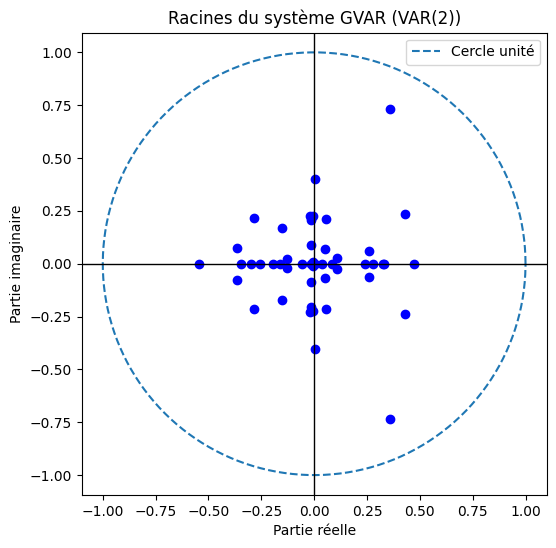

In [102]:
plot_gvar_roots(Phi1, Phi2)

### Quelques représentations graphiques des effets estimés par le GVAR

Matrice des effets contemporains par secteur et par zone géographique

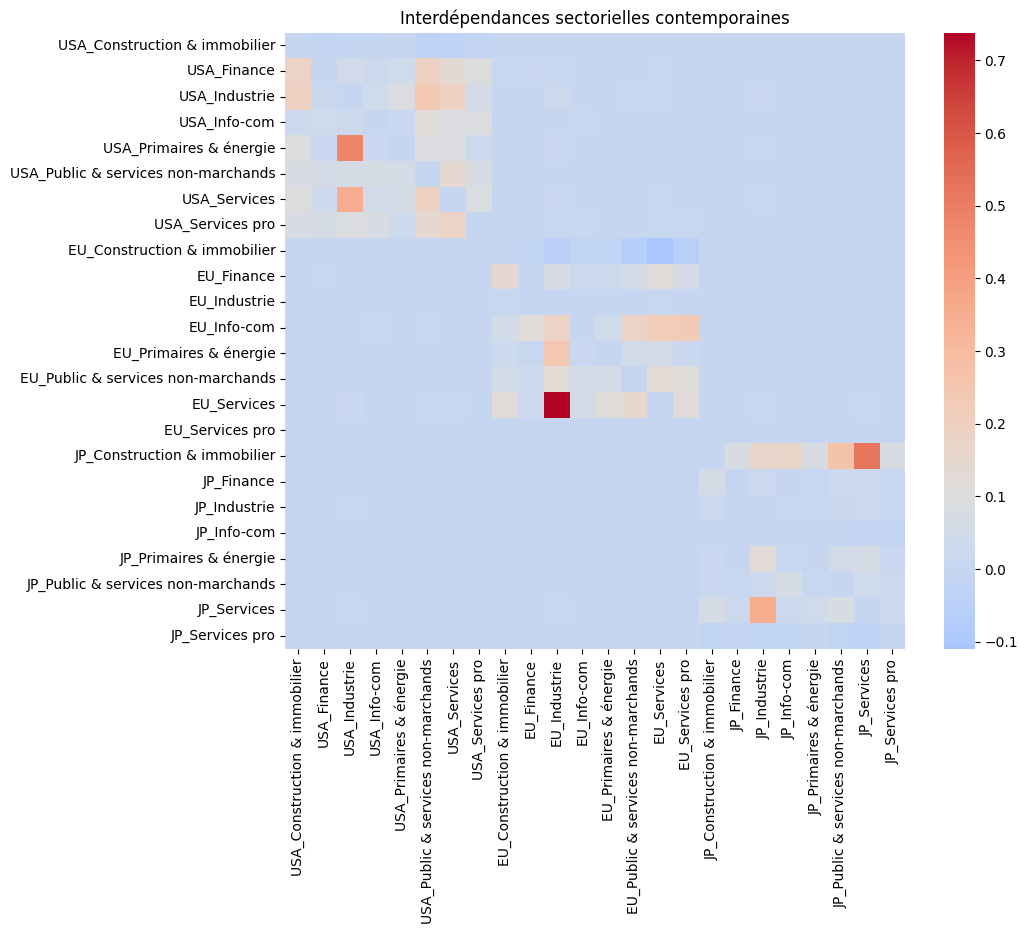

In [103]:
sector_effects = Lambda0 @ W_global
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(sector_effects, cmap="coolwarm", center=0.1)
plt.title("Interdépendances sectorielles contemporaines")
plt.show()

Matrice de propagation des effets du trimestre précédent

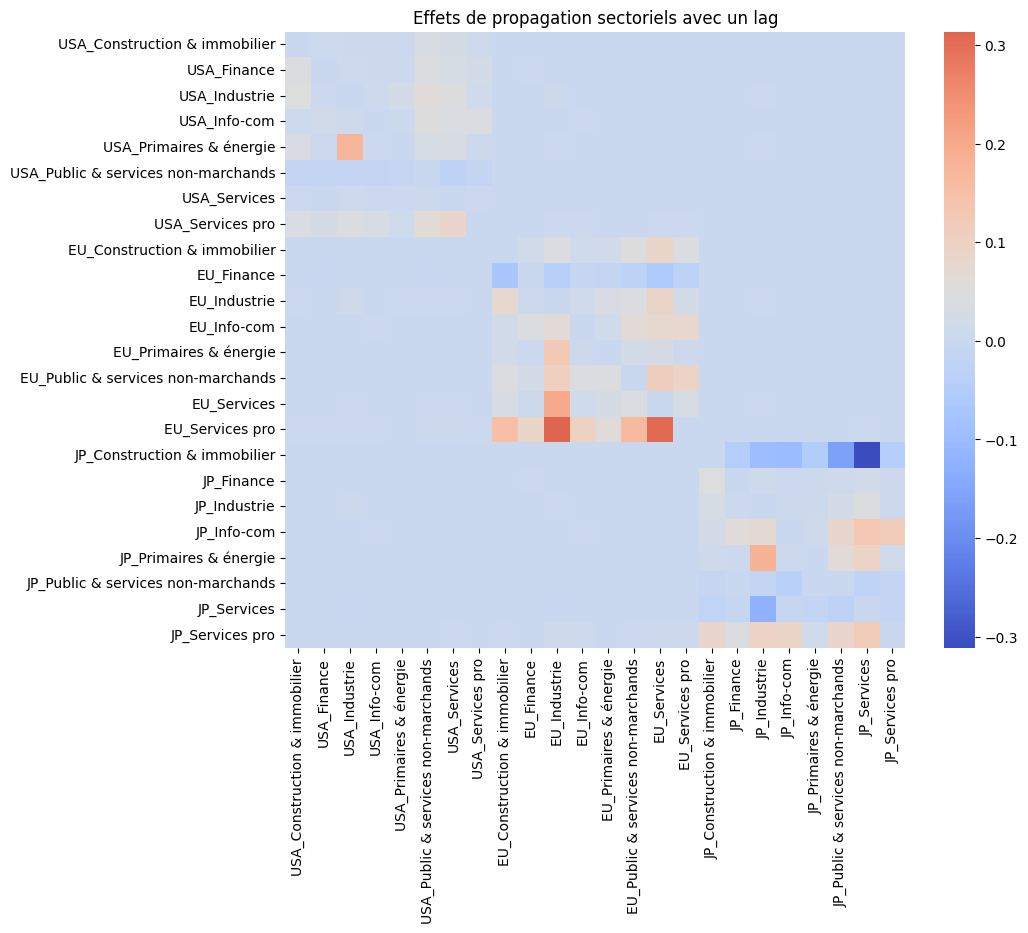

In [104]:
sector_lag1_effects = Lambda1 @ W_global
plt.figure(figsize=(10,8))
sns.heatmap(sector_lag1_effects, cmap="coolwarm", center=0.05)
plt.title("Effets de propagation sectoriels avec un lag")
plt.show()

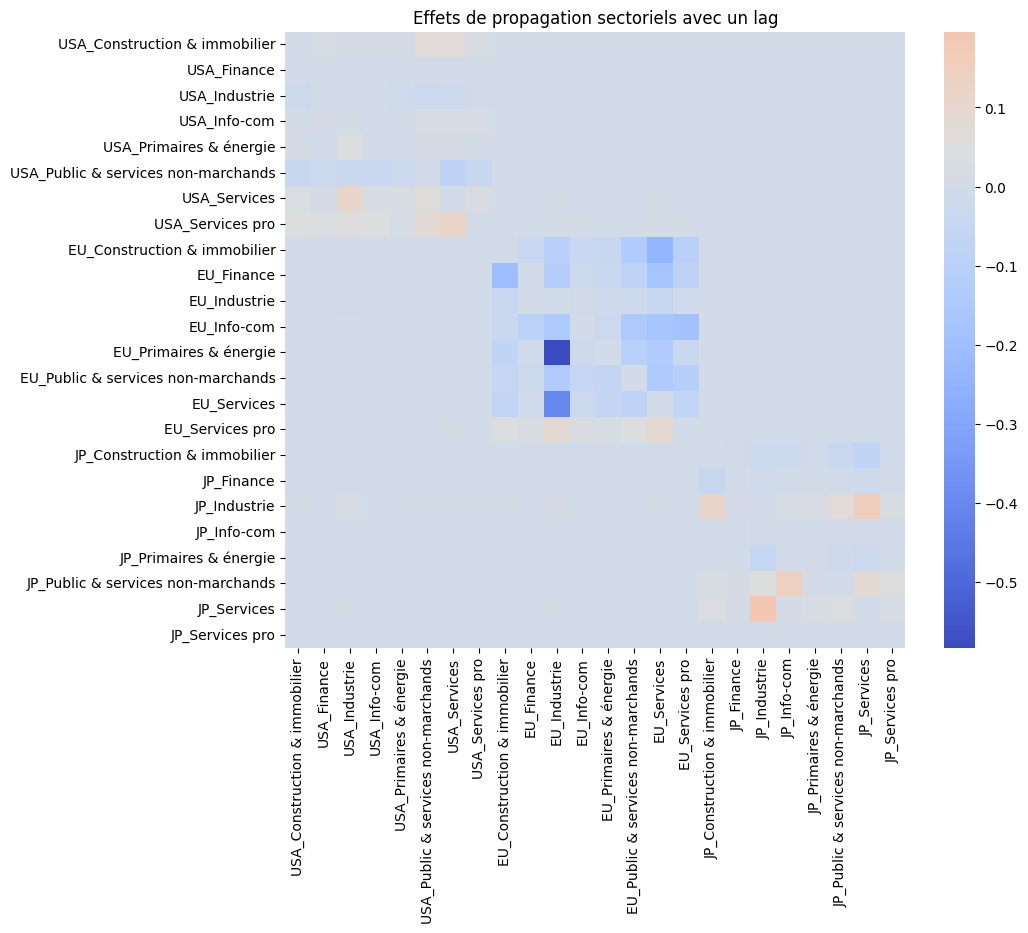

In [105]:
sector_lag2_effects = Lambda2 @ W_global
plt.figure(figsize=(10,8))
sns.heatmap(sector_lag2_effects, cmap="coolwarm", center=0.05)
plt.title("Effets de propagation sectoriels avec un lag")
plt.show()

Influence totale

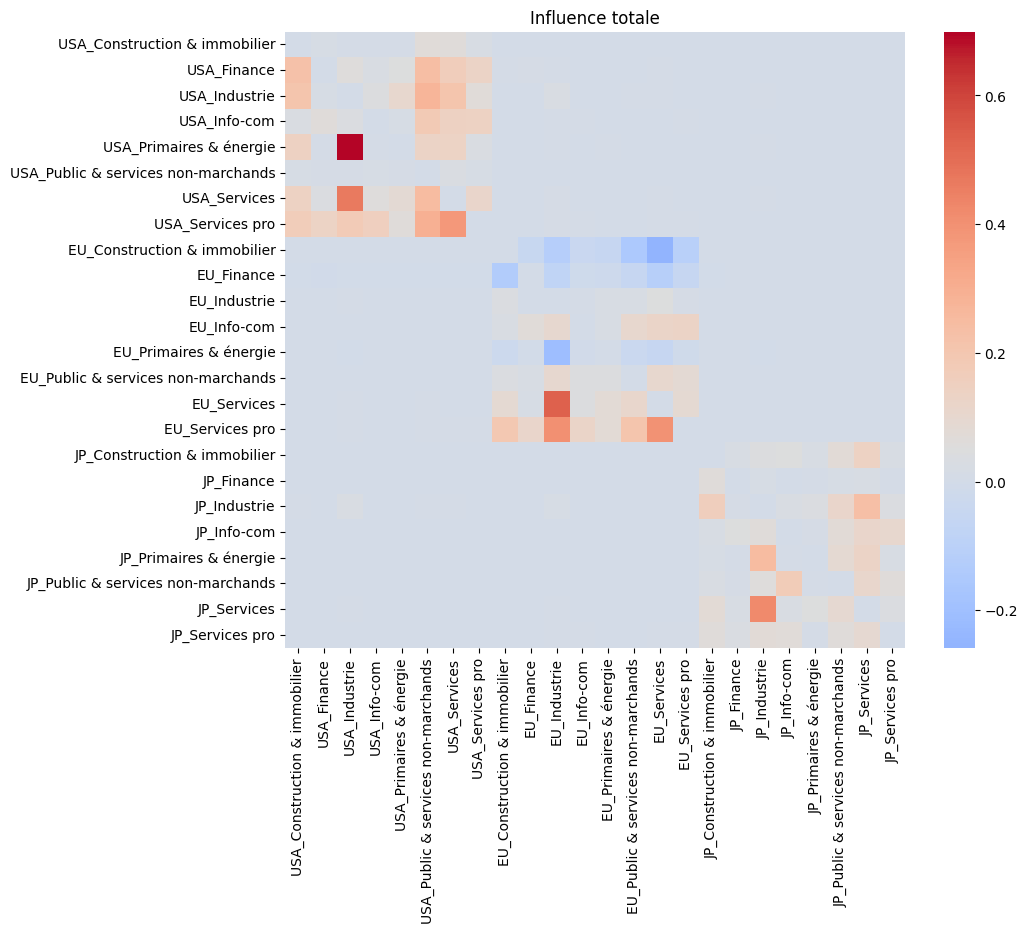

In [107]:
total_sector_effect = sector_effects + sector_lag1_effects + sector_lag2_effects
plt.figure(figsize=(10,8))
sns.heatmap(total_sector_effect, cmap="coolwarm", center=0.05)
plt.title("Influence totale")
plt.show()

Les secteurs qui influencent le plus les autres

In [ ]:
sector_influence = sector_effects.abs().sum(axis=0)
sector_influence.sort_values(ascending=False)

Les secteurs les plus sensibles aux autres

In [ ]:
sector_sensitivity = sector_effects.abs().sum(axis=1)
sector_sensitivity.sort_values(ascending=False)

Effet marginaux des variables macro via le système du GVAR

In [108]:
A0_inv = pd.DataFrame(
    np.linalg.inv(A0.values),
    index=A0.index,
    columns=A0.columns
)

B = A0_inv @ Gamma

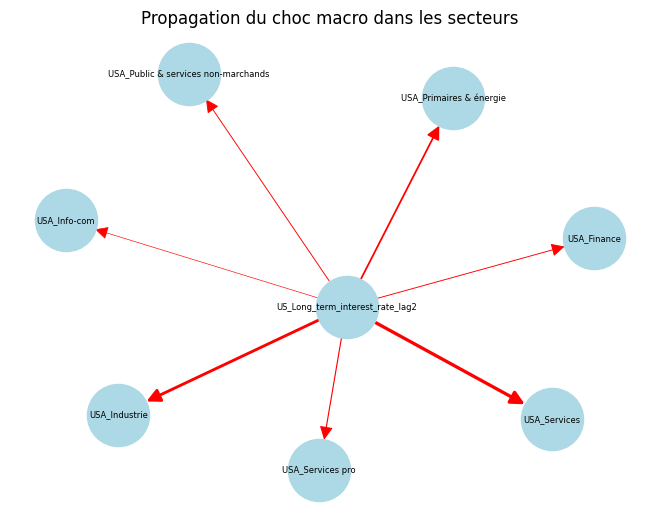

In [111]:
import networkx as nx
import matplotlib.pyplot as plt

macro = "US_Long_term_interest_rate_lag2"

G = nx.DiGraph()

edges = []

for sector, val in B[macro].items():

    if abs(val) > 0.05:   # seuil

        G.add_edge(macro, sector, weight=abs(val), sign=np.sign(val))
        edges.append((macro, sector, val))

pos = nx.spring_layout(G, seed=42)

# largeur proportionnelle
weights = [abs(v) * 5 for _,_,v in edges]

# couleur selon le signe
colors = ["red" if v < 0 else "blue" for _,_,v in edges]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    width=weights,
    edge_color=colors,
    arrowsize=20,
    font_size=6
)

plt.title("Propagation du choc macro dans les secteurs")
plt.show()

In [112]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def plot_top_affected_sectors(
    sector_matrix: pd.DataFrame,
    source_sector: str,
    top_n: int = 8,
    figsize: tuple = (10, 7),
    seed: int = 1
):
    """
    Affiche un réseau orienté depuis un secteur source vers les top_n secteurs
    les plus affectés selon la matrice sectorielle.

    Parameters
    ----------
    sector_matrix : pd.DataFrame
        Matrice des effets sectoriels, typiquement Lambda0 @ W_global.
        Les lignes = secteurs cibles, les colonnes = secteurs sources.
    source_sector : str
        Nom du secteur source (doit être dans les colonnes de sector_matrix).
    top_n : int
        Nombre de secteurs cibles à afficher.
    figsize : tuple
        Taille de la figure.
    seed : int
        Seed pour le layout networkx.
    """

    if source_sector not in sector_matrix.columns:
        raise ValueError(f"{source_sector} n'existe pas dans les colonnes de sector_matrix.")

    # Effets du secteur source sur tous les secteurs cibles
    effects = sector_matrix[source_sector].copy()

    # On enlève l'auto-effet éventuel
    if source_sector in effects.index:
        effects = effects.drop(index=source_sector)

    # On garde les top_n effets en valeur absolue
    top_effects = effects.reindex(
        effects.abs().sort_values(ascending=False).head(top_n).index
    )

    # Création du graphe
    G = nx.DiGraph()
    G.add_node(source_sector)

    for target_sector, val in top_effects.items():
        G.add_edge(
            source_sector,
            target_sector,
            weight=abs(val),
            sign=np.sign(val),
            value=val
        )

    # Position : source au centre-gauche, cibles autour
    pos = nx.spring_layout(G, seed=seed)

    # Styles
    edges = list(G.edges(data=True))
    weights = [d["weight"] * 8 for (_, _, d) in edges]
    colors = ["red" if d["sign"] < 0 else "blue" for (_, _, d) in edges]

    # Taille des noeuds
    node_sizes = []
    for node in G.nodes():
        if node == source_sector:
            node_sizes.append(3200)
        else:
            node_sizes.append(2200)

    plt.figure(figsize=figsize)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=node_sizes,
        node_color=["gold" if node == source_sector else "lightblue" for node in G.nodes()],
        width=weights,
        edge_color=colors,
        arrowsize=20,
        font_size=10
    )

    # Ajouter les labels des coefficients sur les flèches
    edge_labels = {
        (u, v): f"{d['value']:.3f}"
        for u, v, d in edges
    }
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=9
    )

    plt.title(f"Top {top_n} secteurs les plus affectés par {source_sector}")
    plt.axis("off")
    plt.show()

    return top_effects

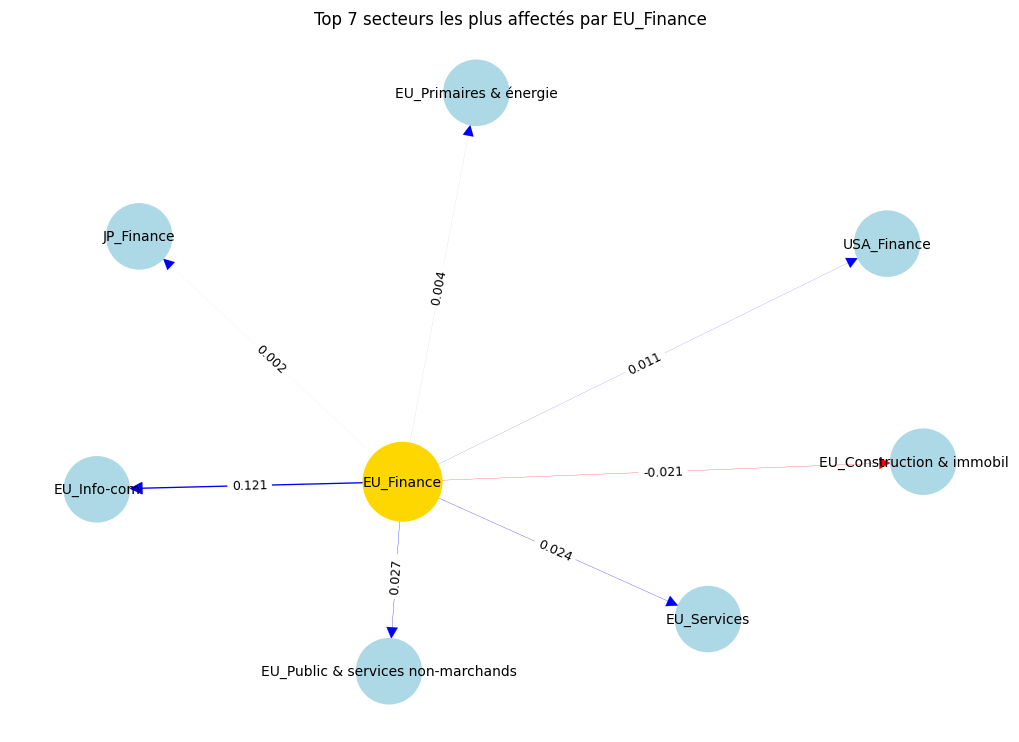

EU_Info-com                           0.120768
EU_Public & services non-marchands    0.026923
EU_Services                           0.024266
EU_Construction & immobilier         -0.020532
USA_Finance                           0.011155
EU_Primaires & énergie                0.003746
JP_Finance                            0.001601
Name: EU_Finance, dtype: float64


In [113]:
sector_matrix = Lambda0 @ W_global

top_effects = plot_top_affected_sectors(
    sector_matrix=sector_matrix,
    source_sector="EU_Finance",
    top_n=7
)

print(top_effects)

In [114]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

In [115]:
def sankey_zone_to_zone(sector_matrix: pd.DataFrame):
    """
    Agrège les effets sectoriels en flux zone -> zone.
    """
    links = sector_matrix.stack().reset_index()
    links.columns = ["source_sector", "target_sector", "value"]

    links = links[links["value"] != 0].copy()

    links["source_zone"] = links["source_sector"].str.split("_").str[0]
    links["target_zone"] = links["target_sector"].str.split("_").str[0]
    links["abs_value"] = links["value"].abs()

    zone_links = (
        links.groupby(["source_zone", "target_zone"], as_index=False)["abs_value"]
        .sum()
    )

    labels = sorted(set(zone_links["source_zone"]).union(set(zone_links["target_zone"])))
    label_to_id = {label: i for i, label in enumerate(labels)}

    source = zone_links["source_zone"].map(label_to_id).tolist()
    target = zone_links["target_zone"].map(label_to_id).tolist()
    values = zone_links["abs_value"].tolist()

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=25,
            thickness=22,
            line=dict(color="black", width=0.5),
            label=labels
        ),
        link=dict(
            source=source,
            target=target,
            value=values
        )
    )])

    fig.update_layout(
        title_text="Sankey – flux d'interdépendance entre zones",
        font_size=12,
        height=600
    )
    fig.show()

In [116]:
sector_matrix = Lambda0 @ W_global
sankey_zone_to_zone(sector_matrix)

In [117]:
def sankey_macro_to_sectors(B: pd.DataFrame, macro: str, top_n: int = 12, use_abs=True):
    """
    Sankey d'une variable macro vers les secteurs.
    
    B : matrice des effets totaux (secteurs x macros)
    macro : nom de la variable macro
    top_n : nombre de secteurs les plus touchés à afficher
    use_abs : si True, on classe par effet absolu
    """
    effects = B[macro].copy()

    if use_abs:
        effects = effects.reindex(effects.abs().sort_values(ascending=False).head(top_n).index)
    else:
        effects = effects.sort_values(ascending=False).head(top_n)

    sectors = effects.index.tolist()

    labels = [macro] + sectors
    source = [0] * len(sectors)
    target = list(range(1, len(sectors) + 1))
    values = effects.abs().tolist()

    # couleur selon le signe
    link_colors = [
        "rgba(31,119,180,0.6)" if v >= 0 else "rgba(214,39,40,0.6)"
        for v in effects.values
    ]

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=labels
        ),
        link=dict(
            source=source,
            target=target,
            value=values,
            color=link_colors,
            customdata=np.round(effects.values, 4),
            hovertemplate="Source: %{source.label}<br>Cible: %{target.label}<br>Effet: %{customdata}<extra></extra>"
        )
    )])

    fig.update_layout(
        title_text=f"Sankey – propagation de {macro} vers les secteurs",
        font_size=11,
        height=700
    )
    fig.show()

In [122]:
sankey_macro_to_sectors(B, macro="US_Long_term_interest_rate_lag2", top_n=15)

In [123]:
sankey_macro_to_sectors(B, macro="EU_Central_bank_Intervention_rate_policy_interest_rate", top_n=10)

In [121]:
sankey_macro_to_sectors(B, macro="US_Unemployment_rate_hp_gap_lag1", top_n=10)

In [125]:
import re
import numpy as np
import pandas as pd
import plotly.graph_objects as go

def translate_sector_name(sector_name: str) -> str:
    """
    Translate sector names from the current French-style labels to clean English labels.
    Example:
        'USA_Construction & immobilier' -> 'USA Construction & Real Estate'
    """
    mapping = {
        "Construction & immobilier": "Construction & Real Estate",
        "Finance": "Finance",
        "Industrie": "Industry",
        "Info-com": "Information & Communication",
        "Primaires & énergie": "Primary Activities & Energy",
        "Public & services non-marchands": "Public & Non-Market Services",
        "Services": "Services",
        "Services pro": "Professional Services",
    }

    if "_" not in sector_name:
        return sector_name

    zone, sector = sector_name.split("_", 1)
    sector_en = mapping.get(sector, sector)
    return f"{zone} {sector_en}"

In [126]:
def sankey_macro_to_sectors_beautiful(
    B: pd.DataFrame,
    macro: str,
    top_n: int = 12,
    use_abs: bool = True,
    title: str | None = None
):
    """
    Elegant Sankey diagram showing the sectoral decomposition of a macroeconomic effect.

    Parameters
    ----------
    B : pd.DataFrame
        Matrix of total effects (rows = sectors, columns = macro variables).
    macro : str
        Name of the macroeconomic variable.
    top_n : int
        Number of most affected sectors to display.
    use_abs : bool
        If True, rank sectors by absolute effect.
    title : str | None
        Custom title. If None, a default English title is used.
    """

    if macro not in B.columns:
        raise ValueError(f"{macro} is not in B.columns")

    effects = B[macro].copy()

    if use_abs:
        effects = effects.reindex(
            effects.abs().sort_values(ascending=False).head(top_n).index
        )
    else:
        effects = effects.sort_values(ascending=False).head(top_n)

    # ---------- Clean English labels ----------
    macro_label = macro.replace("_", " ")
    sector_labels_raw = effects.index.tolist()
    sector_labels = [translate_sector_name(s) for s in sector_labels_raw]

    labels = [macro_label] + sector_labels

    # ---------- Node colors ----------
    # Source node: elegant dark blue
    source_color = "rgba(35, 64, 95, 0.95)"

    # Sector node colors by region
    zone_colors = {
        "USA": "rgba(106, 141, 115, 0.90)",   # sage green
        "EU":  "rgba(113, 132, 171, 0.90)",   # muted steel blue
        "JP":  "rgba(180, 140, 110, 0.90)",   # soft copper
    }

    node_colors = [source_color]
    for s in sector_labels_raw:
        zone = s.split("_")[0]
        node_colors.append(zone_colors.get(zone, "rgba(160,160,160,0.9)"))

    # ---------- Links ----------
    source = [0] * len(sector_labels_raw)
    target = list(range(1, len(sector_labels_raw) + 1))
    values = effects.abs().tolist()

    # Positive / negative effect colors
    positive_link = "rgba(76, 120, 168, 0.45)"   # soft blue
    negative_link = "rgba(192, 80, 77, 0.45)"    # muted red

    link_colors = [
        positive_link if v >= 0 else negative_link
        for v in effects.values
    ]

    # ---------- Hover text ----------
    customdata = np.column_stack([
        np.round(effects.values, 4),
        np.round(effects.abs().values, 4)
    ])

    # ---------- Figure ----------
    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=24,
                    thickness=24,
                    line=dict(color="rgba(70,70,70,0.25)", width=0.6),
                    label=labels,
                    color=node_colors,
                    hovertemplate="%{label}<extra></extra>"
                ),
                link=dict(
                    source=source,
                    target=target,
                    value=values,
                    color=link_colors,
                    customdata=customdata,
                    hovertemplate=(
                        "Source: %{source.label}<br>"
                        "Target: %{target.label}<br>"
                        "Signed effect: %{customdata[0]}<br>"
                        "Absolute effect: %{customdata[1]}<extra></extra>"
                    )
                )
            )
        ]
    )

    final_title = title or f"Sectoral decomposition of the effect of {macro_label}"

    fig.update_layout(
        title=dict(
            text=final_title,
            x=0.5,
            xanchor="center",
            font=dict(size=22)
        ),
        font=dict(
            family="Arial",
            size=13,
            color="rgba(35,35,35,1)"
        ),
        paper_bgcolor="white",
        plot_bgcolor="white",
        width=1200,
        height=760,
        margin=dict(l=40, r=40, t=90, b=30)
    )

    fig.show()

In [128]:
sankey_macro_to_sectors_beautiful(
    B=B,
    macro="US_Long_term_interest_rate_lag2",
    top_n=15
)

In [129]:
def sankey_macro_region_sector(
    B: pd.DataFrame,
    macro: str,
    top_n: int = 12,
    use_abs: bool = True,
    title: str | None = None
):
    """
    Elegant 3-level Sankey diagram:
    Macro variable -> Region -> Sector

    Parameters
    ----------
    B : pd.DataFrame
        Matrix of total effects (rows = sectors, columns = macro variables).
    macro : str
        Name of the macroeconomic variable.
    top_n : int
        Number of most affected sectors to display.
    use_abs : bool
        If True, rank sectors by absolute effect.
    title : str | None
        Custom chart title.
    """

    if macro not in B.columns:
        raise ValueError(f"{macro} is not in B.columns")

    effects = B[macro].copy()

    if use_abs:
        effects = effects.reindex(
            effects.abs().sort_values(ascending=False).head(top_n).index
        )
    else:
        effects = effects.sort_values(ascending=False).head(top_n)

    # ---------- Raw and translated labels ----------
    macro_label = macro.replace("_", " ")
    sector_raw = effects.index.tolist()
    sector_labels = [translate_sector_name(s) for s in sector_raw]

    # regions present among selected sectors
    regions = []
    for s in sector_raw:
        reg = s.split("_")[0]
        if reg not in regions:
            regions.append(reg)

    # ---------- Labels ----------
    labels = [macro_label] + regions + sector_labels

    macro_idx = 0
    region_idx = {r: i + 1 for i, r in enumerate(regions)}
    sector_idx = {
        s_raw: 1 + len(regions) + i
        for i, s_raw in enumerate(sector_raw)
    }

    # ---------- Colors ----------
    source_color = "rgba(35, 64, 95, 0.96)"

    region_colors = {
        "USA": "rgba(106, 141, 115, 0.95)",   # sage green
        "EU":  "rgba(113, 132, 171, 0.95)",   # muted blue
        "JP":  "rgba(180, 140, 110, 0.95)",   # soft copper
    }

    node_colors = [source_color]
    node_colors += [region_colors.get(r, "rgba(150,150,150,0.95)") for r in regions]
    node_colors += [region_colors.get(s.split('_')[0], "rgba(150,150,150,0.85)") for s in sector_raw]

    # ---------- Links ----------
    # 1) Macro -> Region
    region_abs = {}
    for s, val in effects.items():
        reg = s.split("_")[0]
        region_abs[reg] = region_abs.get(reg, 0.0) + abs(val)

    source = []
    target = []
    value = []
    color = []
    customdata = []

    macro_to_region_color = {
        "USA": "rgba(106, 141, 115, 0.35)",
        "EU":  "rgba(113, 132, 171, 0.35)",
        "JP":  "rgba(180, 140, 110, 0.35)",
    }

    for reg in regions:
        source.append(macro_idx)
        target.append(region_idx[reg])
        value.append(region_abs[reg])
        color.append(macro_to_region_color.get(reg, "rgba(150,150,150,0.35)"))
        customdata.append([reg, np.nan, round(region_abs[reg], 4)])

    # 2) Region -> Sector
    positive_link = "rgba(76, 120, 168, 0.45)"
    negative_link = "rgba(192, 80, 77, 0.45)"

    for s, val in effects.items():
        reg = s.split("_")[0]
        source.append(region_idx[reg])
        target.append(sector_idx[s])
        value.append(abs(val))
        color.append(positive_link if val >= 0 else negative_link)
        customdata.append([reg, round(val, 4), round(abs(val), 4)])

    customdata = np.array(customdata, dtype=object)

    # ---------- Figure ----------
    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=24,
                    thickness=24,
                    line=dict(color="rgba(70,70,70,0.25)", width=0.6),
                    label=labels,
                    color=node_colors,
                    hovertemplate="%{label}<extra></extra>"
                ),
                link=dict(
                    source=source,
                    target=target,
                    value=value,
                    color=color,
                    customdata=customdata,
                    hovertemplate=(
                        "Source: %{source.label}<br>"
                        "Target: %{target.label}<br>"
                        "Signed effect: %{customdata[1]}<br>"
                        "Absolute contribution: %{customdata[2]}<extra></extra>"
                    )
                )
            )
        ]
    )

    final_title = title or f"Sectoral decomposition of the effect of {macro_label}"

    fig.update_layout(
        title=dict(
            text=final_title,
            x=0.5,
            xanchor="center",
            font=dict(size=22)
        ),
        font=dict(
            family="Arial",
            size=13,
            color="rgba(35,35,35,1)"
        ),
        paper_bgcolor="white",
        plot_bgcolor="white",
        width=1300,
        height=780,
        margin=dict(l=40, r=40, t=90, b=30)
    )

    fig.show()

In [131]:
sankey_macro_region_sector(
    B=B,
    macro="US_Long_term_interest_rate_lag2",
    top_n=24
)

In [133]:
def sankey_macro_region_sector_beautiful(
    B: pd.DataFrame,
    macro: str,
    top_n: int = 12,
    use_abs: bool = True,
    title: str | None = None
):
    if macro not in B.columns:
        raise ValueError(f"{macro} is not in B.columns")

    effects = B[macro].copy()

    if use_abs:
        effects = effects.reindex(
            effects.abs().sort_values(ascending=False).head(top_n).index
        )
    else:
        effects = effects.sort_values(ascending=False).head(top_n)

    # ---------- Labels ----------
    macro_label = macro.replace("_", " ")
    sector_raw = effects.index.tolist()
    sector_labels = [translate_sector_name(s) for s in sector_raw]

    regions = []
    for s in sector_raw:
        r = s.split("_")[0]
        if r not in regions:
            regions.append(r)

    labels = [macro_label] + regions + sector_labels

    macro_idx = 0
    region_idx = {r: i + 1 for i, r in enumerate(regions)}
    sector_idx = {
        s: 1 + len(regions) + i
        for i, s in enumerate(sector_raw)
    }

    # ---------- COLORS (NEW PALETTE) ----------
    # Source (macro)
    source_color = "rgba(28, 56, 89, 0.95)"  # deep elegant blue

    # Regions
    region_colors = {
        "USA": "rgba(90, 130, 200, 0.90)",   # soft blue
        "EU":  "rgba(170, 150, 210, 0.90)",  # light violet
        "JP":  "rgba(210, 185, 150, 0.90)",  # beige
    }

    # Nodes
    node_colors = [source_color]
    node_colors += [region_colors.get(r, "rgba(180,180,180,0.9)") for r in regions]
    node_colors += [
        region_colors.get(s.split("_")[0], "rgba(200,200,200,0.8)")
        for s in sector_raw
    ]

    # ---------- LINKS ----------
    source = []
    target = []
    value = []
    color = []
    customdata = []

    # Macro → Region
    region_abs = {}
    for s, val in effects.items():
        r = s.split("_")[0]
        region_abs[r] = region_abs.get(r, 0) + abs(val)

    macro_region_colors = {
        "USA": "rgba(90, 130, 200, 0.35)",
        "EU":  "rgba(170, 150, 210, 0.35)",
        "JP":  "rgba(210, 185, 150, 0.35)",
    }

    for r in regions:
        source.append(macro_idx)
        target.append(region_idx[r])
        value.append(region_abs[r])
        color.append(macro_region_colors.get(r, "rgba(180,180,180,0.3)"))
        customdata.append([r, np.nan, round(region_abs[r], 4)])

    # Region → Sector
    positive_link = "rgba(90, 130, 200, 0.45)"   # blue
    negative_link = "rgba(180, 120, 120, 0.45)"  # muted red

    for s, val in effects.items():
        r = s.split("_")[0]
        source.append(region_idx[r])
        target.append(sector_idx[s])
        value.append(abs(val))
        color.append(positive_link if val >= 0 else negative_link)
        customdata.append([r, round(val, 4), round(abs(val), 4)])

    customdata = np.array(customdata, dtype=object)

    # ---------- FIGURE ----------
    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=26,
                    thickness=26,
                    line=dict(color="rgba(120,120,120,0.2)", width=0.6),
                    label=labels,
                    color=node_colors,
                    hovertemplate="%{label}<extra></extra>"
                ),
                link=dict(
                    source=source,
                    target=target,
                    value=value,
                    color=color,
                    customdata=customdata,
                    hovertemplate=(
                        "Source: %{source.label}<br>"
                        "Target: %{target.label}<br>"
                        "Signed effect: %{customdata[1]}<br>"
                        "Absolute contribution: %{customdata[2]}<extra></extra>"
                    )
                )
            )
        ]
    )

    final_title = title or f"Sectoral decomposition of the effect of {macro_label}"

    fig.update_layout(
        title=dict(
            text=final_title,
            x=0.5,
            xanchor="center",
            font=dict(size=22, color="rgba(30,30,30,1)")
        ),
        font=dict(
            family="Arial",
            size=13,
            color="rgba(40,40,40,1)"
        ),
        paper_bgcolor="white",
        plot_bgcolor="white",
        width=1300,
        height=780,
        margin=dict(l=40, r=40, t=90, b=30)
    )

    fig.show()

In [135]:
sankey_macro_region_sector_beautiful(
    B=B,
    macro="US_Long_term_interest_rate_lag2",
    top_n=24,
    title="Decomposition of the effect of US long-term interest rate (lag 2) on sectors"
)

In [136]:
sankey_macro_region_sector_beautiful(
    B=B,
    macro="EU_Central_bank_Intervention_rate_policy_interest_rate",
    top_n=24,
    title="Decomposition of the effect of EU central bank intervention rate policy interest rate on sectors"
)

In [137]:
sankey_macro_region_sector_beautiful(
    B=B,
    macro="JP_Inflation_rate_lag2",
    top_n=24,
    title="Decomposition of the effect of JP inflation rate (lag 2) on sectors"
)

### Fonctions de reponses impulsionnelles

In [ ]:
def build_companion_matrix(Phi1: pd.DataFrame, Phi2: pd.DataFrame):
    
    N = Phi1.shape[0]

    top = np.hstack([Phi1.values, Phi2.values])
    bottom = np.hstack([np.eye(N), np.zeros((N, N))])

    companion = np.vstack([top, bottom])

    return companion

In [ ]:
def irf_sector_shock(
    Phi1: pd.DataFrame,
    Phi2: pd.DataFrame,
    shock_sector: str,
    horizon: int = 12,
    shock_size: float = 1.0
):

    sectors = list(Phi1.index)

    if shock_sector not in sectors:
        raise ValueError(f"{shock_sector} n'est pas dans Phi.index")

    N = len(sectors)

    companion = build_companion_matrix(Phi1, Phi2)

    # vecteur choc
    e = np.zeros(2 * N)
    e[sectors.index(shock_sector)] = shock_size

    responses = []

    for h in range(horizon + 1):

        Phi_h = np.linalg.matrix_power(companion, h)

        resp = Phi_h @ e

        responses.append(resp[:N])  # seulement z_t

    irf_df = pd.DataFrame(
        responses,
        columns=sectors,
        index=range(horizon + 1)
    )

    irf_df.index.name = "horizon"

    return irf_df

In [ ]:
def plot_irf_top_sectors(irf_df: pd.DataFrame, title: str, top_n: int = 8, criterion: str = "peak"):
    
    if criterion == "peak":
        scores = irf_df.abs().max(axis=0)
    elif criterion == "final":
        scores = irf_df.iloc[-1].abs()
    else:
        raise ValueError("criterion doit être 'peak' ou 'final'")
    
    top_sectors = scores.sort_values(ascending=False).head(top_n).index
    
    plt.figure(figsize=(10, 6))
    
    for sector in top_sectors:
        plt.plot(irf_df.index, irf_df[sector], label=sector)
    
    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("Horizon")
    plt.ylabel("Réponse")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [ ]:
irf_eu_info_com = irf_sector_shock(
    Phi1,
    Phi2,
    shock_sector="EU_Info-com",
    horizon=12
)

plot_irf_top_sectors(
    irf_eu_info_com,
    title="IRF – choc sur EU_Info-com"
)

In [ ]:
irf_usa_industrie = irf_sector_shock(
    Phi1,
    Phi2,
    shock_sector="USA_Industrie",
    horizon=12
)

plot_irf_top_sectors(
    irf_usa_industrie,
    title="IRF – choc sur USA_Industrie"
)

In [ ]:
irf_jp_industrie = irf_sector_shock(Phi, shock_sector="JP_Industrie", horizon=12, shock_size=1.0)
plot_irf_top_sectors(
    irf_jp_industrie,
    title="IRF à un choc sectoriel sur JP_Industrie",
    top_n=10
)

### Effets marginaux des variables macro

In [ ]:
def dynamic_marginal_effect(
    Phi1: pd.DataFrame,
    Phi2: pd.DataFrame,
    B: pd.DataFrame,
    exog_var: str,
    horizon: int = 12,
    shock_size: float = 1.0
):

    if exog_var not in B.columns:
        raise ValueError(f"{exog_var} n'est pas dans B.columns")

    sectors = list(Phi1.index)
    N = len(sectors)

    companion = build_companion_matrix(Phi1, Phi2)

    impact0 = shock_size * B[exog_var].values

    shock_vec = np.zeros(2 * N)
    shock_vec[:N] = impact0

    responses = []

    for h in range(horizon + 1):

        Phi_h = np.linalg.matrix_power(companion, h)

        resp = Phi_h @ shock_vec

        responses.append(resp[:N])

    out = pd.DataFrame(
        responses,
        columns=sectors,
        index=range(horizon + 1)
    )

    out.index.name = "horizon"

    return out

In [ ]:
dme_house = dynamic_marginal_effect(
    Phi1,
    Phi2,
    B,
    exog_var="US_House_prices_residential_hp_gap",
    horizon=12
)

plot_irf_top_sectors(
    dme_house,
    title="Propagation dynamique du choc immobilier US"
)

### Réponse impulsionnelle secteur à secteur

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def inv_df(M: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        np.linalg.inv(M.values),
        index=M.index,
        columns=M.columns
    )

In [77]:
def build_companion_matrix(Phi1: pd.DataFrame, Phi2: pd.DataFrame) -> pd.DataFrame:
    N = Phi1.shape[0]

    top = np.hstack([Phi1.values, Phi2.values])
    bottom = np.hstack([np.eye(N), np.zeros((N, N))])

    comp = np.vstack([top, bottom])

    index = list(Phi1.index) + [f"{s}_lag1" for s in Phi1.index]
    columns = list(Phi1.columns) + [f"{s}_lag1" for s in Phi1.columns]

    return pd.DataFrame(comp, index=index, columns=columns)

In [78]:
def irf_sector_pair(
    Phi1: pd.DataFrame,
    Phi2: pd.DataFrame,
    shock_sector: str,
    response_sector: str,
    horizon: int = 12,
    shock_size: float = 1.0
) -> pd.Series:
    sectors = list(Phi1.index)

    if shock_sector not in sectors:
        raise ValueError(f"{shock_sector} n'est pas dans Phi1.index")
    if response_sector not in sectors:
        raise ValueError(f"{response_sector} n'est pas dans Phi1.index")

    N = len(sectors)
    companion = build_companion_matrix(Phi1, Phi2)

    shock_vec = np.zeros(2 * N)
    shock_vec[sectors.index(shock_sector)] = shock_size

    responses = []

    for h in range(horizon + 1):
        C_h = np.linalg.matrix_power(companion.values, h)
        resp_h = C_h @ shock_vec
        responses.append(resp_h[sectors.index(response_sector)])

    out = pd.Series(responses, index=range(horizon + 1), name=response_sector)
    out.index.name = "horizon"
    return out

In [79]:
def assemble_gvar_from_param_dict(param_dict, Z_cols, macro_cols, W):
    if list(W.index) != list(Z_cols) or list(W.columns) != list(Z_cols):
        raise ValueError("W n'est pas alignée sur Z_cols.")

    N = len(Z_cols)

    c_vec = pd.Series(0.0, index=Z_cols, name="const")
    lambda0 = pd.Series(0.0, index=Z_cols, name="lambda0")
    lambda1 = pd.Series(0.0, index=Z_cols, name="lambda1")
    lambda2 = pd.Series(0.0, index=Z_cols, name="lambda2")
    Gamma = pd.DataFrame(0.0, index=Z_cols, columns=macro_cols)

    for z in Z_cols:
        params = param_dict[z]

        c_vec.loc[z] = params.get("const", 0.0)
        lambda0.loc[z] = params.get(f"{z}_star", 0.0)
        lambda1.loc[z] = params.get(f"{z}_star_lag1", 0.0)
        lambda2.loc[z] = params.get(f"{z}_star_lag2", 0.0)

        for m in macro_cols:
            Gamma.loc[z, m] = params.get(m, 0.0)

    Lambda0 = pd.DataFrame(np.diag(lambda0.values), index=Z_cols, columns=Z_cols)
    Lambda1 = pd.DataFrame(np.diag(lambda1.values), index=Z_cols, columns=Z_cols)
    Lambda2 = pd.DataFrame(np.diag(lambda2.values), index=Z_cols, columns=Z_cols)

    I = pd.DataFrame(np.eye(N), index=Z_cols, columns=Z_cols)

    A0 = I - Lambda0 @ W
    A1 = Lambda1 @ W
    A2 = Lambda2 @ W

    A0_inv = inv_df(A0)

    Phi1 = A0_inv @ A1
    Phi2 = A0_inv @ A2

    return {
        "c_vec": c_vec,
        "Gamma": Gamma,
        "Lambda0": Lambda0,
        "Lambda1": Lambda1,
        "Lambda2": Lambda2,
        "A0": A0,
        "A1": A1,
        "A2": A2,
        "Phi1": Phi1,
        "Phi2": Phi2,
    }

In [80]:
def irf_sector_pair_with_ci(
    results: dict,
    Z_cols: list,
    macro_cols: list,
    W: pd.DataFrame,
    shock_sector: str,
    response_sector: str,
    horizon: int = 12,
    shock_size: float = 1.0,
    n_draws: int = 1000,
    ci: float = 0.95,
    seed: int = 42
):
    rng = np.random.default_rng(seed)

    # point estimate
    point_params = {z: results[z].params.copy() for z in Z_cols}
    assembled = assemble_gvar_from_param_dict(point_params, Z_cols, macro_cols, W)

    point_irf = irf_sector_pair(
        assembled["Phi1"],
        assembled["Phi2"],
        shock_sector=shock_sector,
        response_sector=response_sector,
        horizon=horizon,
        shock_size=shock_size
    )

    # simulations
    all_irfs = []

    for _ in range(n_draws):
        sampled_params = {}

        valid_draw = True

        for z in Z_cols:
            model = results[z]
            mean = model.params.values
            cov = model.cov_params().values
            names = model.params.index.tolist()

            try:
                draw = rng.multivariate_normal(mean=mean, cov=cov)
            except np.linalg.LinAlgError:
                valid_draw = False
                break

            sampled_params[z] = pd.Series(draw, index=names)

        if not valid_draw:
            continue

        try:
            assembled_b = assemble_gvar_from_param_dict(sampled_params, Z_cols, macro_cols, W)

            # on saute les tirages instables ou singuliers
            Phi1_b = assembled_b["Phi1"]
            Phi2_b = assembled_b["Phi2"]
            companion_b = build_companion_matrix(Phi1_b, Phi2_b)
            eigvals_b = np.linalg.eigvals(companion_b.values)

            if np.max(np.abs(eigvals_b)) >= 1:
                continue

            irf_b = irf_sector_pair(
                Phi1_b,
                Phi2_b,
                shock_sector=shock_sector,
                response_sector=response_sector,
                horizon=horizon,
                shock_size=shock_size
            )

            all_irfs.append(irf_b.values)

        except Exception:
            continue

    if len(all_irfs) == 0:
        raise ValueError("Aucun tirage bootstrap/simulé valide. Réduis n_draws ou vérifie le modèle.")

    all_irfs = np.array(all_irfs)

    alpha = 1 - ci
    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    lower = np.percentile(all_irfs, lower_q, axis=0)
    upper = np.percentile(all_irfs, upper_q, axis=0)
    median = np.median(all_irfs, axis=0)

    out = pd.DataFrame({
        "horizon": range(horizon + 1),
        "irf": point_irf.values,
        "median": median,
        "lower": lower,
        "upper": upper
    }).set_index("horizon")

    return out

In [81]:
def plot_irf_sector_pair_beautiful(
    irf_ci_df: pd.DataFrame,
    shock_sector: str,
    response_sector: str,
    ci_label: str = "95% CI",
    subtitle: str | None = None
):
    x = irf_ci_df.index.values
    y = irf_ci_df["irf"].values
    lower = irf_ci_df["lower"].values
    upper = irf_ci_df["upper"].values

    peak_idx = int(np.argmax(np.abs(y)))
    peak_x = x[peak_idx]
    peak_y = y[peak_idx]

    plt.figure(figsize=(11, 6.5))

    # bande de confiance
    plt.fill_between(
        x, lower, upper,
        alpha=0.20,
        linewidth=0,
        label=ci_label
    )

    # ligne centrale
    plt.plot(
        x, y,
        linewidth=2.6,
        label="IRF"
    )

    # ligne zéro
    plt.axhline(0, linewidth=1.2, alpha=0.7)

    # point de pic
    plt.scatter([peak_x], [peak_y], s=45, zorder=5)
    plt.annotate(
        f"Pic: {peak_y:.3f}\nH={peak_x}",
        xy=(peak_x, peak_y),
        xytext=(10, 12),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", alpha=0.12)
    )

    title = f"Impulse response : {response_sector} to a shock in {shock_sector}"
    plt.title(title, fontsize=15, pad=14)

    if subtitle:
        plt.suptitle(subtitle, y=0.94, fontsize=10, alpha=0.8)

    plt.xlabel("Horizon (trimester)", fontsize=12)
    plt.ylabel("Response", fontsize=12)

    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

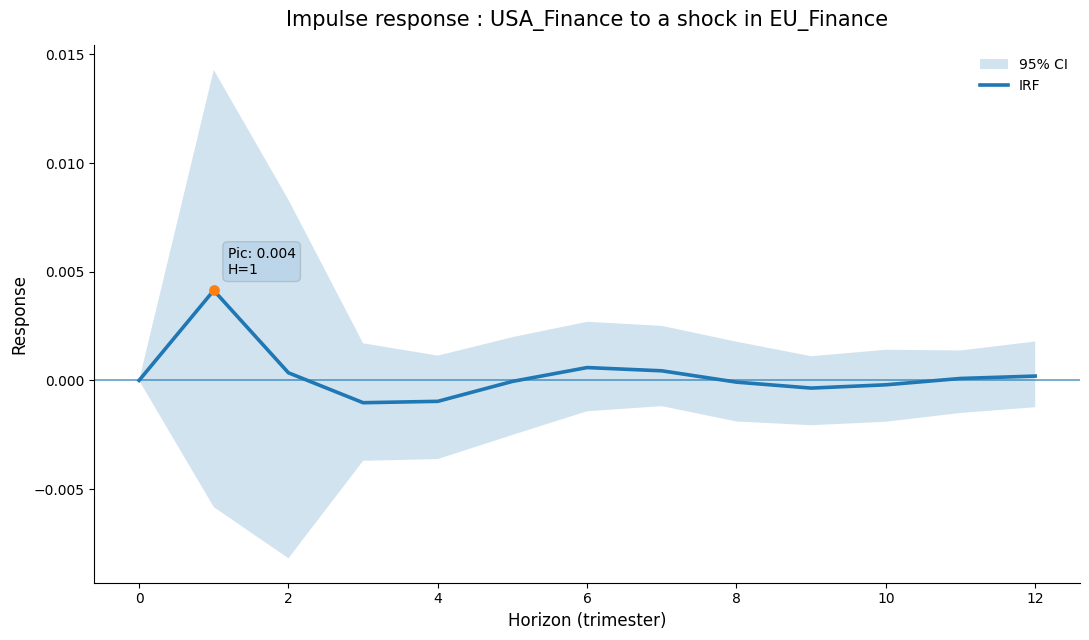

In [82]:
irf_ci_eu_fin_to_us_fin = irf_sector_pair_with_ci(
    results=results,
    Z_cols=Z_cols,
    macro_cols=macro_cols_all,
    W=W_global,
    shock_sector="EU_Finance",
    response_sector="USA_Finance",
    horizon=12,
    shock_size=1.0,
    n_draws=1000,
    ci=0.95,
    seed=123
)

plot_irf_sector_pair_beautiful(
    irf_ci_eu_fin_to_us_fin,
    shock_sector="EU_Finance",
    response_sector="USA_Finance"
)

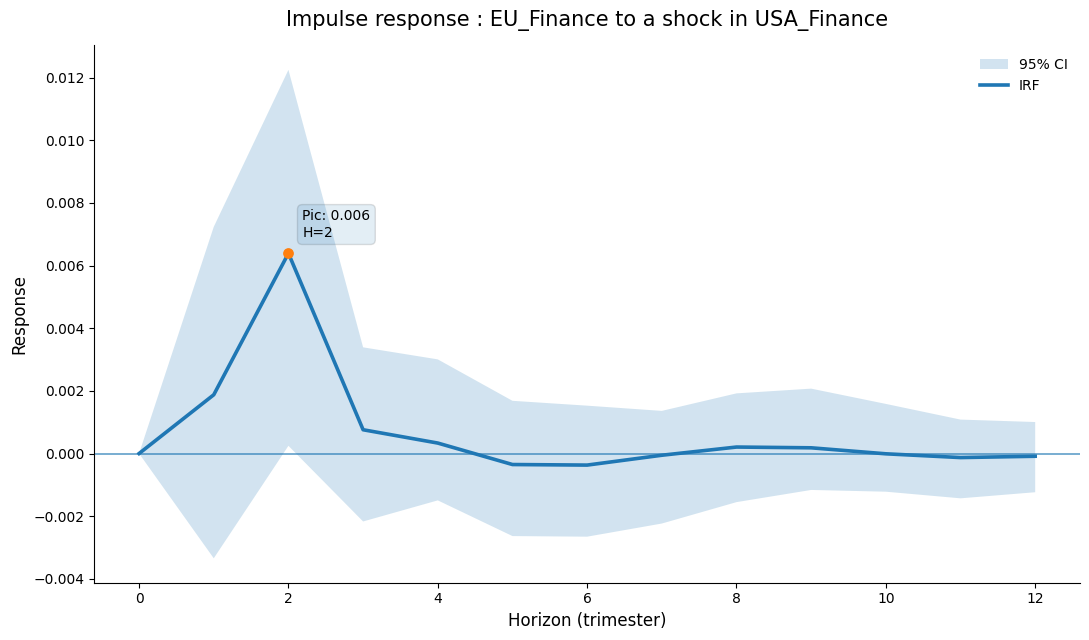

In [86]:
irf_ci_us_fin_to_eu_fin = irf_sector_pair_with_ci(
    results=results,
    Z_cols=Z_cols,
    macro_cols=macro_cols_all,
    W=W_global,
    shock_sector="USA_Finance",
    response_sector="EU_Finance",
    horizon=12,
    shock_size=-1.0,
    n_draws=800,
    ci=0.95,
    seed=123
)

plot_irf_sector_pair_beautiful(
    irf_ci_us_fin_to_eu_fin,
    shock_sector="USA_Finance",
    response_sector="EU_Finance"
)

In [ ]:
irf_ci_us_fin_to_us_fin = irf_sector_pair_with_ci(
    results=results,
    Z_cols=Z_cols,
    macro_cols=macro_cols_all,
    W=W_global,
    shock_sector="USA_Finance",
    response_sector="USA_Finance",
    horizon=12,
    shock_size=-1.0,
    n_draws=800,
    ci=0.95,
    seed=123
)

plot_irf_sector_pair_beautiful(
    irf_ci_us_fin_to_us_fin,
    shock_sector="USA_Finance",
    response_sector="USA_Finance"
)

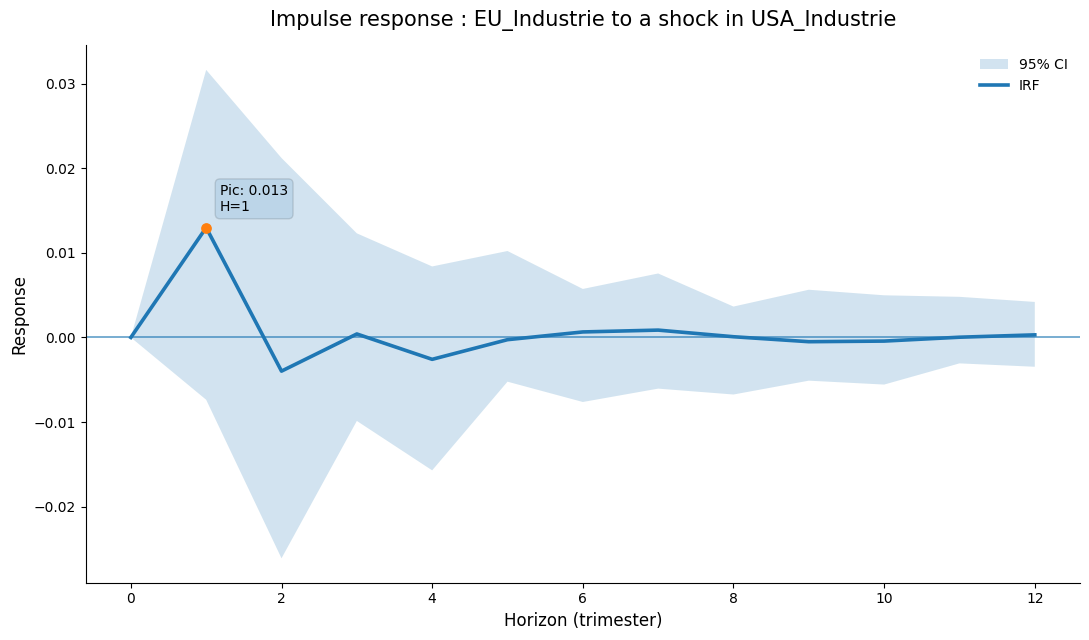

In [84]:
irf_ci_us_ind_to_eu_ind = irf_sector_pair_with_ci(
    results=results,
    Z_cols=Z_cols,
    macro_cols=macro_cols_all,
    W=W_global,
    shock_sector="USA_Industrie",
    response_sector="EU_Industrie",
    horizon=12,
    shock_size=1.0,
    n_draws=800,
    ci=0.95,
    seed=123
)

plot_irf_sector_pair_beautiful(
    irf_ci_us_ind_to_eu_ind,
    shock_sector="USA_Industrie",
    response_sector="EU_Industrie"
)